# Exploratory Data Analysis of Framingham Heart Study
The Framingham Heart Study (FHS) is an ongoing cardiovascular cohort study that began in 1948 in Framingham, Massachusetts.  The intent of the study was to determine common characteristics contributing to Cardiovascular disease (CVD).  The study followed a large group of participants over a long period of time.  Participants who entered the study did not have symptoms of CVD and had not suffered a stroke or heart attack.

The intent of this project is to explore a version of the FHS Dataset that is available on [Kaggle](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset?resource=download).  We will investigate relationships between continuous variables within the dataset and their potential to predict development of CVD.  If these variables are predictive, this could help in early detection and prevention of serious complications arising from CVD.

## About the Data

### Categorical Data
1. **male**: This field is an indicator as to whether the participant is male.  1=male, 0=not male
2. **education**: This field is a numeric indicator of education levels. There is no data to indicate the value these numbers represent.
3. **currentSmoker**: This field is an indicator as to whether the participant is currently a smoker.  1=current smoker, 0=not currently smoking
4. **BPMeds**: This field is an indicator as to whether the participant is currently taking medication to control their blood pressure. 1=currently on meds, 0 = not on meds.
5. **prevalentStroke**: Indicates if the participant has had a stroke. 1=yes, 0=no
6. **prevalentHyp**:  Indicates if the participant has hypertension. 1=yes, 0=no
7. **diabetes**: Indicates if the participant has diabetes. 1=yes, 0=no
8. **TenYearCHD**: Indicates if the participant developed CHD within 10 years of study.

### Other Discreet Data
1. **cigsPerDay**:  Indicates the number of cigarettes per day that the participant smokes.
2. **heartRate**:  indicates the participants heart rate at time of examination.

### Continuous Data
1. **age**: The age of the participant at the time of examination.  This variable is measured in years for the purpose of the study.
2. **totChol**: The Total Cholosteral level of the participant at the time of examination.  This variable is measured in milligrams per deciliter (mg/dL).
3. **sysBP**: The Systolic Blood Pressure of the participant at the time of examination.  This variable is measured in millimeters of mercury (mmHg).
4. **diaBP**: The Diastolic Blood Pressure of the participant at the time of examination.  This variable is measured in millimeters of mercury (mmHg).
5. **bmi**: The Body Mass Index of the participant at the time of examination.  This variable is calculated using the weight and height of the participant as kg/m^2.
6.  **glucose**: The fasting blood glucose level of the participant at the time of examination.  This variable is measured in milligrams per deciliter (mg/dL).

# Selected Variables

For this Exploratory Data Analysis, we will evaluate all continuous data fields as described above.  We will compare these values using PMF, CDF, and other methods.  In addition, we will run hypothesis tests and regression analysis on the variables.

# Pre-Work
In order to prepare for the analysis, we will create a few sections here to handle some common code and data needs.

### Needed Imports
Here, we will import necessary python libraries required for the analysis.

In [1]:
from IPython.display import display, HTML
from scipy.stats import pearsonr
from sklearn.metrics import roc_curve, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore", "use_inf_as_na")

# Load and Initial Exploration of Data Set

## Read in the dataset.

In [3]:
file_path = '../data/framingham.csv'
df = pd.read_csv(file_path)

## Segment variables for euse during analysis

In [4]:
continuous_vars = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'glucose']
discrete_vars = ['male','currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'cigsPerDay', 'heartRate']
target = ['TenYearCHD']

## Display basic dataset information
From this info, we can see that there are a handful of variables which have null values.  These include education, cigsPerday, BPMeds, totChol, BMI, heartRate, and glucose.  Further in our analysis, we will have to determine how to handle these variables.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


## View Random Sample of data in dataset

In [6]:
display(HTML(df.sample(10).to_html()))

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1484,1,61,4.0,0,0.0,0.0,0,0,0,179.0,112.0,66.5,24.38,60.0,100.0,0
2327,0,48,1.0,1,20.0,0.0,0,1,0,252.0,143.0,81.0,24.00,85.0,101.0,0
2618,0,39,1.0,0,0.0,0.0,0,0,0,205.0,139.5,87.0,20.70,67.0,85.0,0
4002,0,46,3.0,0,0.0,0.0,0,0,0,277.0,122.5,77.5,27.42,63.0,77.0,0
130,1,53,1.0,1,30.0,0.0,0,0,0,244.0,106.0,67.5,21.84,88.0,65.0,0
51,1,51,4.0,0,0.0,0.0,0,0,0,216.0,112.0,66.0,23.47,90.0,95.0,0
685,0,45,2.0,0,0.0,0.0,0,1,0,215.0,152.5,82.0,25.92,100.0,75.0,0
2539,0,55,1.0,0,0.0,0.0,0,0,0,215.0,122.0,86.0,30.61,79.0,87.0,0
2878,1,43,1.0,1,20.0,0.0,0,0,0,175.0,103.0,64.5,17.81,86.0,78.0,0
2469,1,48,4.0,1,20.0,0.0,0,1,0,259.0,135.0,90.0,20.72,102.0,81.0,1


## Display dataset summary statistics

In [7]:
display(HTML(df.describe().to_html()))

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Distinct Values Analysis
Here, I'm going to look at the BPMeds field and the education field to see if they provide useful information for analysis.  After viewing the values, I determined that I will use median to impute the BPMeds field.  I could not find information on the specific values of the codes in the education field.  Therefore, I will drop this column from further analysis.

In [8]:
# Get distinct values for BPMeds
bpmeds_unique_values = df['BPMeds'].unique()
print("Distinct values for BPMeds:")
print(bpmeds_unique_values)

# Get distinct values for education
education_unique_values = df['education'].unique()
print("\nDistinct values for education:")
print(education_unique_values)

Distinct values for BPMeds:
[ 0.  1. nan]

Distinct values for education:
[ 4.  2.  1.  3. nan]


### Impute BPMeds using Median

In [9]:
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].median())

### Drop education column

In [10]:
df = df.drop(columns=['education'])

# Identify and Plot Missing Data

## Identify Variables with missing data

In [11]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

# Filter out variables with missing values
missing_values = missing_values[missing_values > 0]

# Display the missing values summary
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
cigsPerDay     29
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


### Display the percentage of missing values for each variable

In [12]:
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100

# Display the percentage of missing values
missing_percentage.round(2)

male               0.00
age                0.00
currentSmoker      0.00
cigsPerDay         0.68
BPMeds             0.00
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.18
sysBP              0.00
diaBP              0.00
BMI                0.45
heartRate          0.02
glucose            9.15
TenYearCHD         0.00
dtype: float64

### Heatmap of missing values
This heatmap shows the record index in the dataframe (y-axis) and whether it is missing a value for a given variable (x-axis).  The darker shade indicates the value is not missing while the lighter shade indicates a missing value.

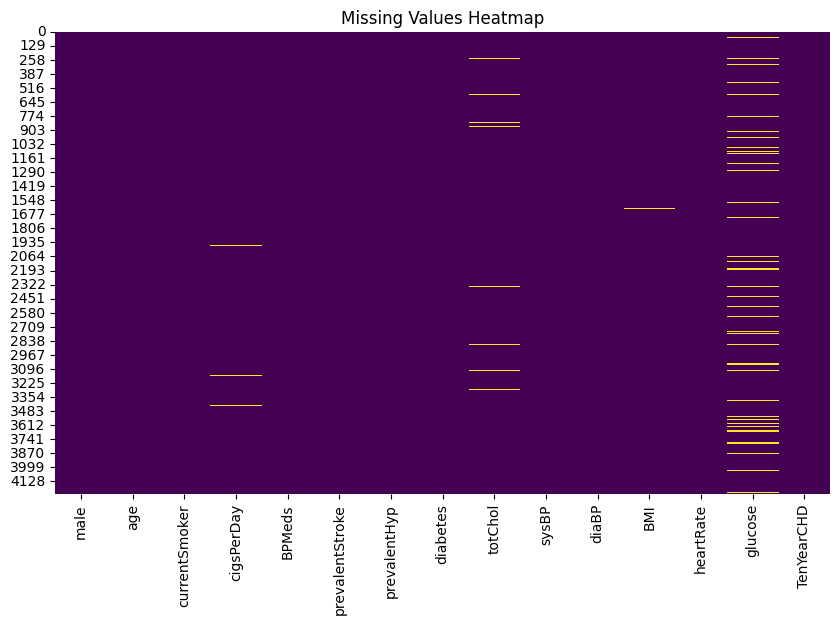

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

## Visualize Distributions to Identify Imputation Methods
When determining imputation method, consider the distribution (normal, peak, flat, outliers, etc).  Data that is symmetric (normal distribution) with low presence of outliers is a good fit for imputing via mean.  Data that is skewed or has a lot of outliers is a good fit for imputing via the median which is less biased from outliers.

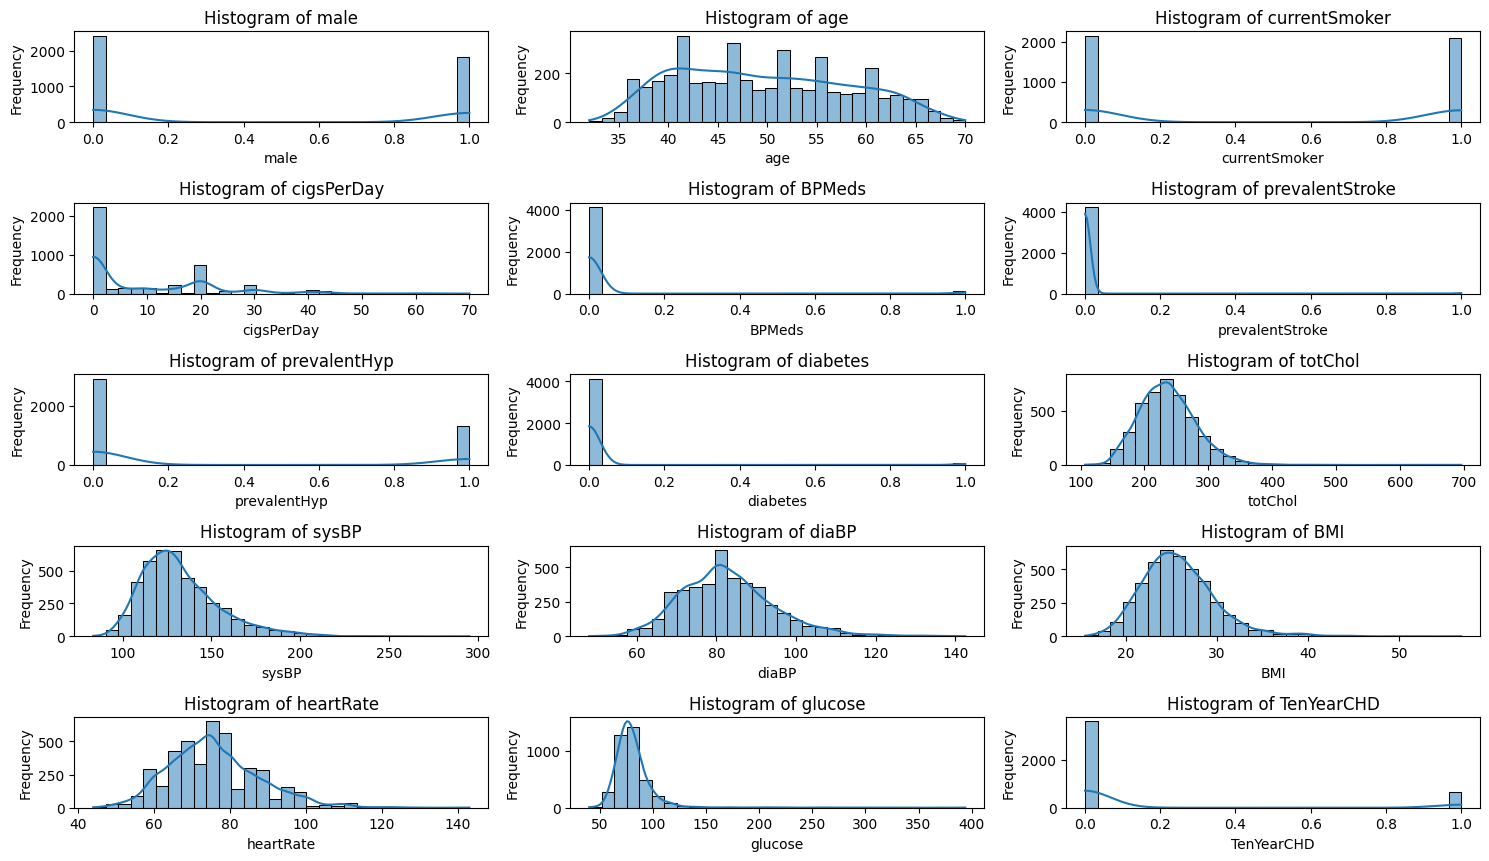

In [14]:
# Create histograms for each variable
plt.figure(figsize=(15, 10))
for i, var in enumerate(df.columns.to_list()):
    plt.subplot(6, 3, i + 1)
    sns.histplot(df[var].dropna(), kde=True, bins=30)  ## seaborn has an old library that throws use_inf_as_na warning, suppressed above
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Impute the missing values
Based on the distributions, I have chosen to use mean for impting age, diaBP, and heartRate.  I will use median to impute totChol, sysBP, BMI, and glucose.  Other values do not need to be imputed.

In [15]:
# Impute missing values for each variable based on the earlier analysis

# Impute using mean
df['age'] = df['age'].fillna(df['age'].mean())
df['diaBP'] = df['diaBP'].fillna(df['diaBP'].mean())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].mean())

# Impute using median
df['totChol'] = df['totChol'].fillna(df['totChol'].median())
df['sysBP'] = df['sysBP'].fillna(df['sysBP'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['glucose'] = df['glucose'].fillna(df['glucose'].median())
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())

# Verify that there are no missing values in the continuous variables
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


### Recalculate the Summary Statistics After Imputation

In [16]:
display(HTML(df.describe().to_html()))

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000
mean,0.429245,49.580189,0.494104,8.944340,0.029245,0.005896,0.310613,0.025708,236.667689,132.354599,82.897759,25.799005,75.878981,81.600943,0.151887
std,0.495027,8.572942,0.500024,11.904777,0.168513,0.076569,0.462799,0.158280,44.328480,22.033300,11.910394,4.070775,12.023929,22.860340,0.358953
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.077500,68.000000,72.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,144.000000,90.000000,28.032500,83.000000,85.000000,0.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


# Plotting for Analysis
Plotting Histograms and Box Plots specific to the continuous variables in the dataset.

## Histogram for all continuous variables

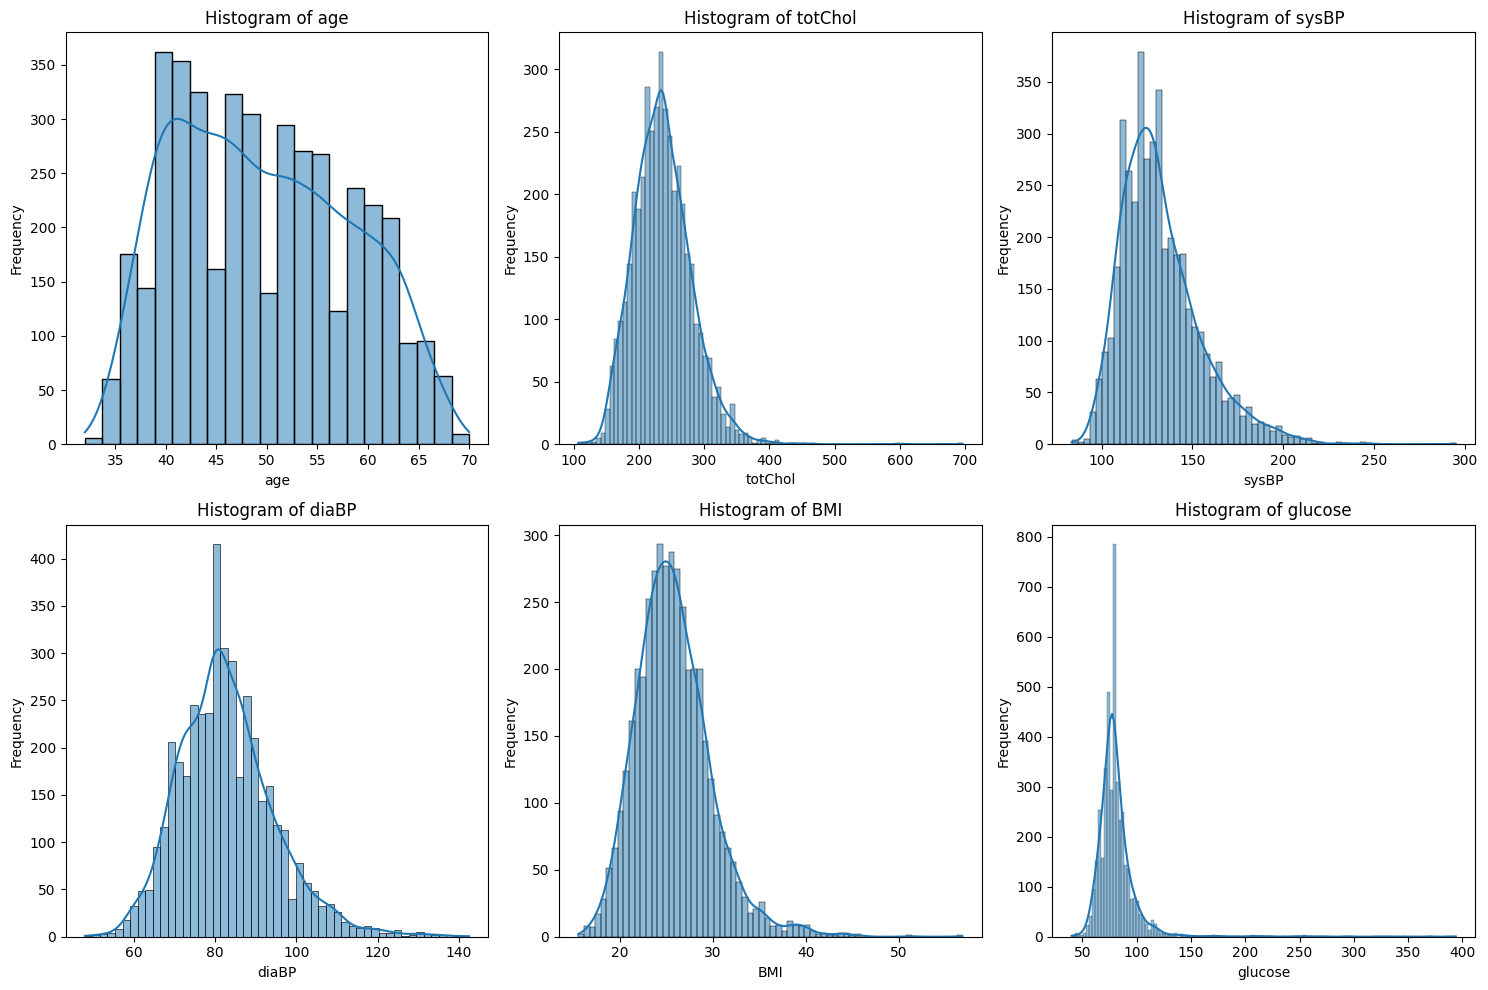

In [17]:
# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Loop through the variables and create a histogram for each
for i, var in enumerate(continuous_vars, 1):
    plt.subplot(2, 3, i) 
    sns.histplot(df[var], kde=True) 
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

## Boxplots for Outliers of Continuous Variables

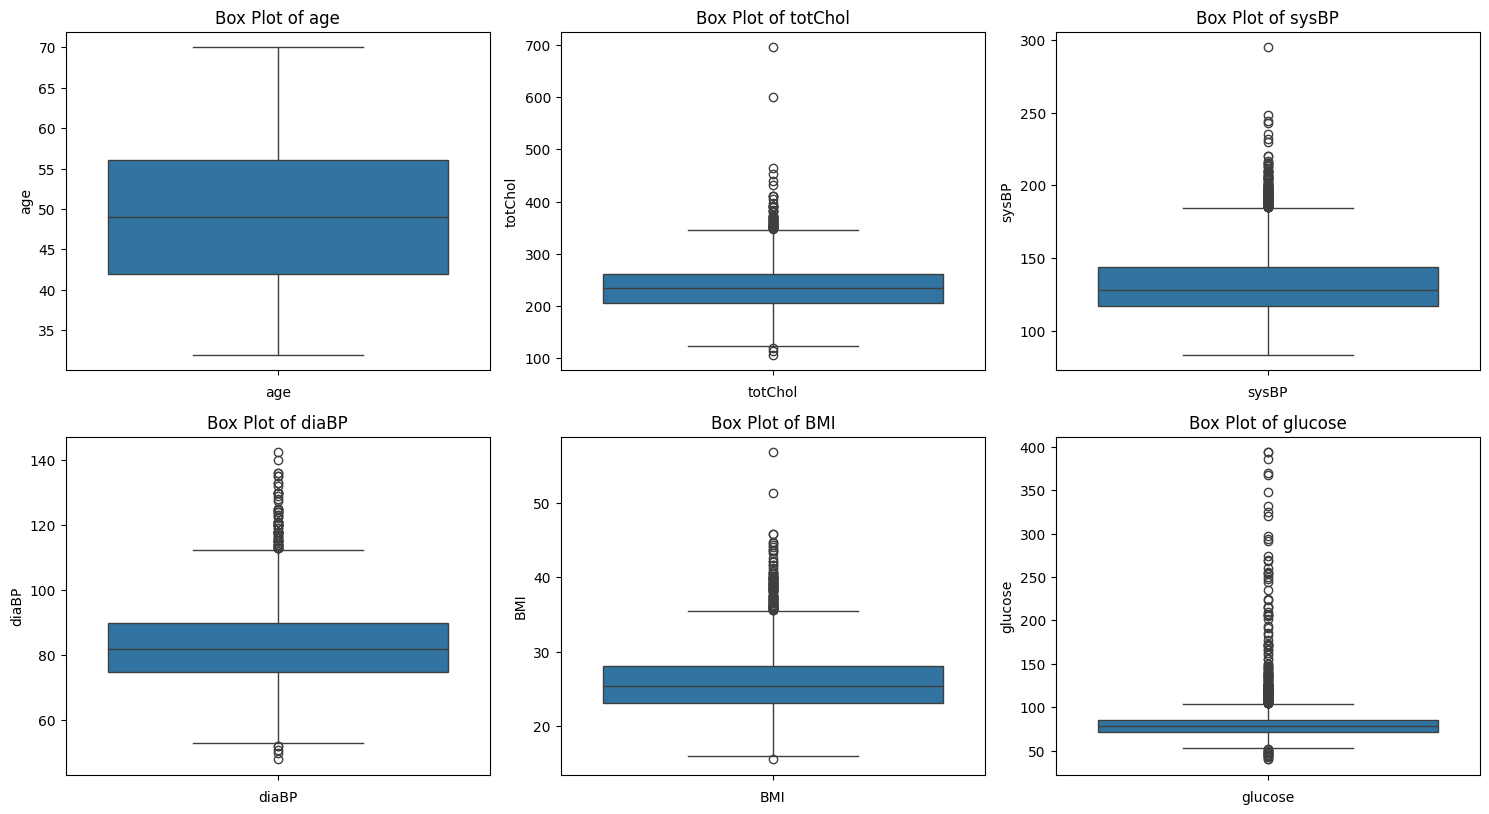

In [18]:
# Set up the plotting area
plt.figure(figsize=(15, 12))

# Loop through each variable and create a subplot for its box plot
for i, var in enumerate(continuous_vars):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, y=var)
    plt.title(f'Box Plot of {var}')
    plt.xlabel(var)

plt.tight_layout()
plt.show()

## Explore Impact of Outliers on Correlations
This section aims to explore whether outliers identified in the above plots should be removed.

### Reusable functions for removing outliers

In [19]:
# Define a function to apply log transformation to specified columns
def log_transform_columns(df, columns):
    df_transformed = df.copy()
    for col in columns:
        # Apply log transformation, adding a small constant to avoid log(0)
        df_transformed[col] = np.log(df_transformed[col] + 1e-9)
    return df_transformed

# Define a function to remove outliers using the IQR method
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

### Correlation matrix with outliers included

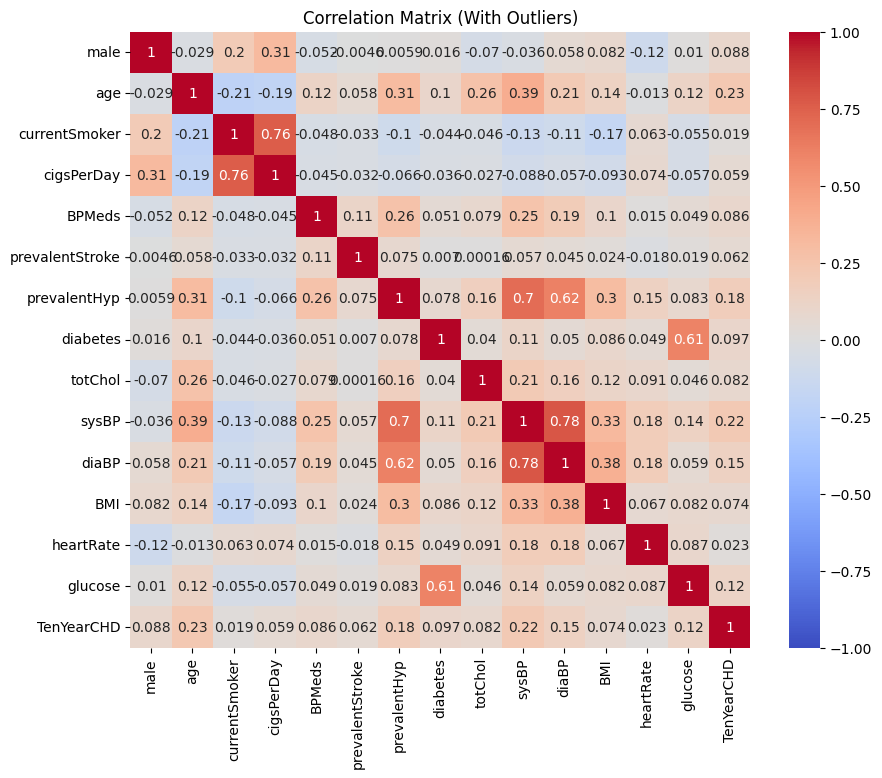

In [20]:
# Calculate the correlation matrix with outliers
correlation_matrix_with_outliers = df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_with_outliers, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (With Outliers)")
plt.show()

### Remove outliers using log transformation.

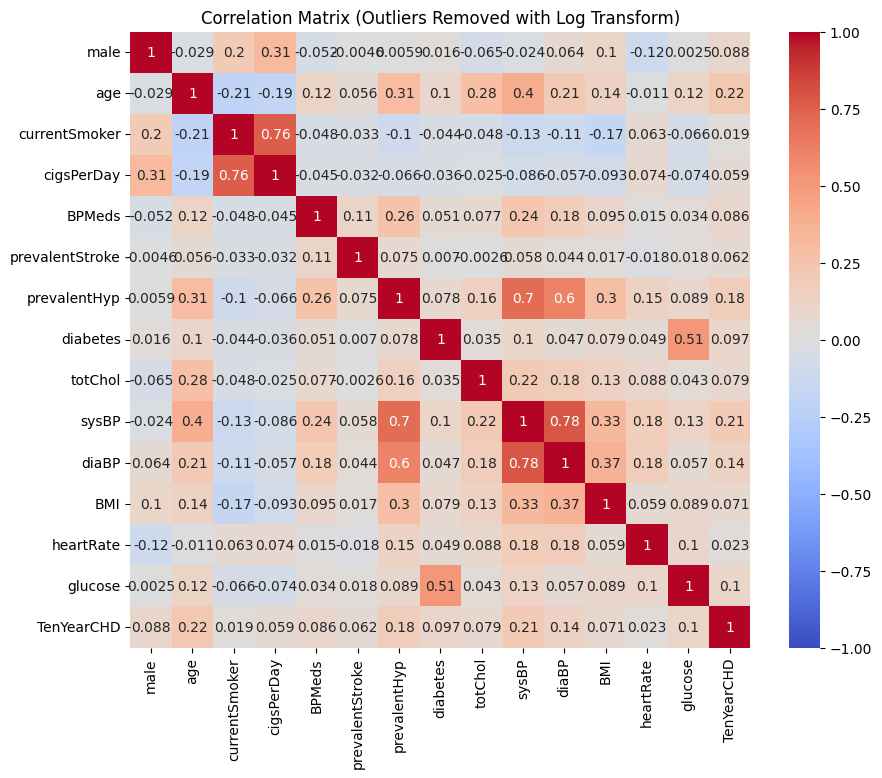

In [21]:
# df_no_outliers = remove_outliers(df, continuous_vars)
df_no_outliers_log = log_transform_columns(df, continuous_vars)

# Calculate the correlation matrix without outliers
correlation_matrix_no_outliers_log = df_no_outliers_log.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_no_outliers_log, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Outliers Removed with Log Transform)")
plt.show()

### Remove outliers using IQR Method

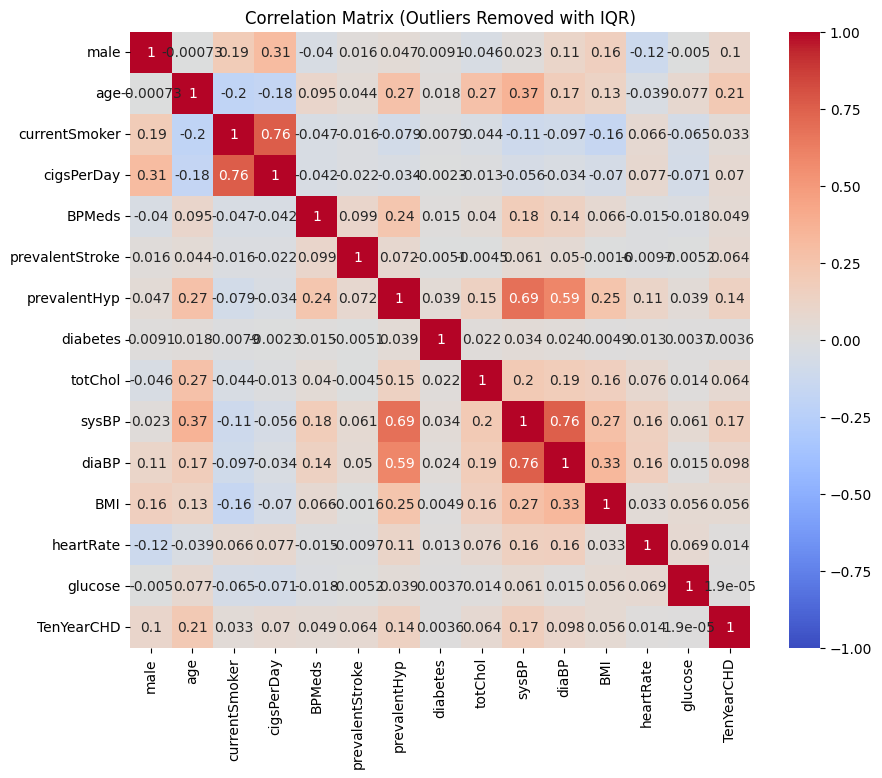

In [22]:
df_no_outliers_iqr = remove_outliers(df, continuous_vars)

# Calculate the correlation matrix without outliers
correlation_matrix_no_outliers_iqr = df_no_outliers_iqr.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_no_outliers_iqr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Outliers Removed with IQR)")
plt.show()

### Compare Correlations and decide how to handle outliers

In [23]:
# Model using all continuous vars to predict TenYearCHD
X = df[continuous_vars]
y = df['TenYearCHD']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

In [24]:
# Fit the model with outliers
model_with_outliers = sm.OLS(y, X).fit()
print("Regression Results with Outliers:")
print(model_with_outliers.summary())

Regression Results with Outliers:
                            OLS Regression Results                            
Dep. Variable:             TenYearCHD   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     58.81
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.39e-70
Time:                        19:09:29   Log-Likelihood:                -1501.9
No. Observations:                4240   AIC:                             3018.
Df Residuals:                    4233   BIC:                             3062.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5

In [25]:
# Fit the model with outliers removed via log transformation
X_no_outliers_log = df_no_outliers_log[continuous_vars]
y_no_outliers_log = df_no_outliers_log['TenYearCHD']
X_no_outliers_log = sm.add_constant(X_no_outliers_log)

model_no_outliers_log = sm.OLS(y_no_outliers_log, X_no_outliers_log).fit()
print("\nRegression Results Outliers removed via Log Transformation:")
print(model_no_outliers_log.summary())


Regression Results Outliers removed via Log Transformation:
                            OLS Regression Results                            
Dep. Variable:             TenYearCHD   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     54.72
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           2.52e-65
Time:                        19:09:29   Log-Likelihood:                -1513.3
No. Observations:                4240   AIC:                             3041.
Df Residuals:                    4233   BIC:                             3085.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [26]:
# Fit the model with outliers removed via IQR method
X_no_outliers_iqr = df_no_outliers_iqr[continuous_vars]
y_no_outliers_iqr = df_no_outliers_iqr['TenYearCHD']
X_no_outliers_iqr = sm.add_constant(X_no_outliers_iqr)

model_no_outliers_iqr = sm.OLS(y_no_outliers_iqr, X_no_outliers_iqr).fit()
print("\nRegression Results with Outliers removed via IQR Method:")
print(model_no_outliers_log.summary())


Regression Results with Outliers removed via IQR Method:
                            OLS Regression Results                            
Dep. Variable:             TenYearCHD   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     54.72
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           2.52e-65
Time:                        19:09:29   Log-Likelihood:                -1513.3
No. Observations:                4240   AIC:                             3041.
Df Residuals:                    4233   BIC:                             3085.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Summary of Outlier Analysis
For this analysis, we looked at how all continuous variables impacted the ability to predict the TenYearCHD.  In this case, removing outliers using IQR or Log Transformation did not improve the model accuracy.  So, for now, we are going to leave outliers in the analysis.  Later, we will evaluate the VIF of these variables to see if adding/removing them from the analysis improves accuracy.  Once we make this decision, we can re-analyze outlier impact and decide if the outliers should be removed.

# Probability Mass Function (PMF) Analysis
This section aims to demonstrate understand of PMFs.  May additional plots for each continuous variable could be analyzed.  However, we limite to a couple of examples.

## Reusable Function to Plot PMFs

In [27]:
# Function to create side-by-side PMF plots for a given variable
def plot_pmf(variable, bins):
    # Bin the variable
    df[f'{variable}_binned'] = pd.cut(df[variable], bins=bins, labels=False)

    # Separate the data into those with and without CHD
    has_chd = df[df['TenYearCHD'] == 1]
    no_chd = df[df['TenYearCHD'] == 0]

    # Calculate the PMF for each group
    pmf_has_chd = has_chd[f'{variable}_binned'].value_counts(normalize=True).sort_index()
    pmf_no_chd = no_chd[f'{variable}_binned'].value_counts(normalize=True).sort_index()

    # Reindex to make sure both have the same index (bins)
    index = pd.Index(range(len(bins) - 1))
    pmf_has_chd = pmf_has_chd.reindex(index, fill_value=0)
    pmf_no_chd = pmf_no_chd.reindex(index, fill_value=0)

    # Determine the position of bars on the x-axis
    bar_width = 0.4
    indices = np.arange(len(pmf_has_chd))

    # Plotting the PMFs side by side
    plt.figure(figsize=(10, 6))
    plt.bar(indices - bar_width/2, pmf_has_chd.values, width=bar_width, alpha=0.7, label='With CHD')
    plt.bar(indices + bar_width/2, pmf_no_chd.values, width=bar_width, alpha=0.7, label='Without CHD')

    # Adding labels and title
    bin_labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]
    plt.xticks(indices, bin_labels, rotation=45)
    plt.xlabel(f'{variable.upper()} Range')
    plt.ylabel('Probability')
    plt.title(f'Side-by-Side PMF of {variable.upper()} for With CHD vs Without CHD')
    plt.legend()
    plt.grid(True)
    plt.show()

## PMF of Age and Those with CHD and Without CHD
From this PMF, we can see that the age ranges between 50 and 65 have the highest probability of having CHD; the highest of these being the 55-60 age range.

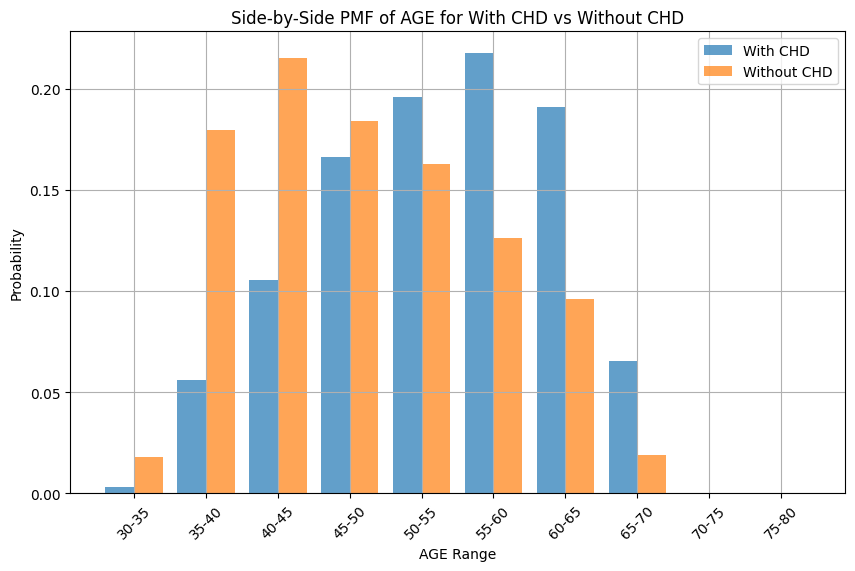

In [28]:
plot_pmf('age', bins=np.arange(30, 85, 5)) 

## PMF of BMI for those with CHD and those without CHD
From this PMF, we can see that BMI over 27 tends to be associated with those with CHD while lower BMI indicates less likelihood of CHD.

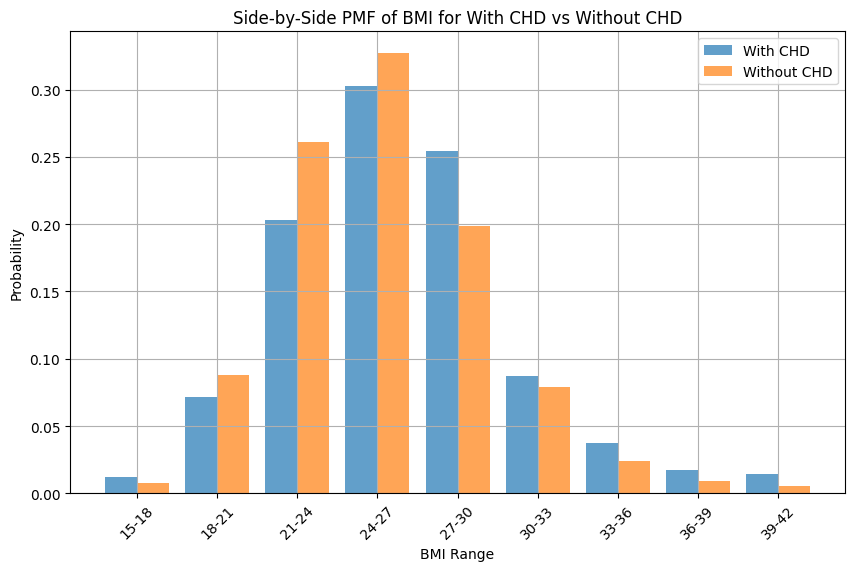

In [29]:
plot_pmf('BMI', bins=np.arange(15, 45, 3))

# Cumulative Distribution Function (CDF) Analysis
This section aims to demonstrate understanding of CDF.  Here, we plot additional CDFs than are required in the project rubric.

In [30]:
## Reusable Function for Plotting CDFs
def plot_cdf(variable):
    # Separate the data into those with and without CHD
    has_chd = df[df['TenYearCHD'] == 1]
    no_chd = df[df['TenYearCHD'] == 0]

    # Sort the data for CDF calculation
    var_has_chd_sorted = np.sort(has_chd[variable])
    var_no_chd_sorted = np.sort(no_chd[variable])

    # Calculate the CDFs
    cdf_has_chd = np.arange(1, len(var_has_chd_sorted) + 1) / len(var_has_chd_sorted)
    cdf_no_chd = np.arange(1, len(var_no_chd_sorted) + 1) / len(var_no_chd_sorted)

    # Plotting the CDFs
    plt.figure(figsize=(10, 6))
    plt.plot(var_has_chd_sorted, cdf_has_chd, marker='.', linestyle='none', label='With CHD')
    plt.plot(var_no_chd_sorted, cdf_no_chd, marker='.', linestyle='none', label='Without CHD')

    # Adding labels and title
    plt.xlabel(variable)
    plt.ylabel('Cumulative Probability')
    plt.title(f'CDF of {variable} for With CHD vs Without CHD')
    plt.legend()
    plt.grid(True)
    plt.show()

## CDF of BMI for those with and without CHD
From this result, we see that the curve for those with and without CHD follows a similar S shape.  The blue line indicates that those with CHD tend to have a higher BMI than those without CHD.

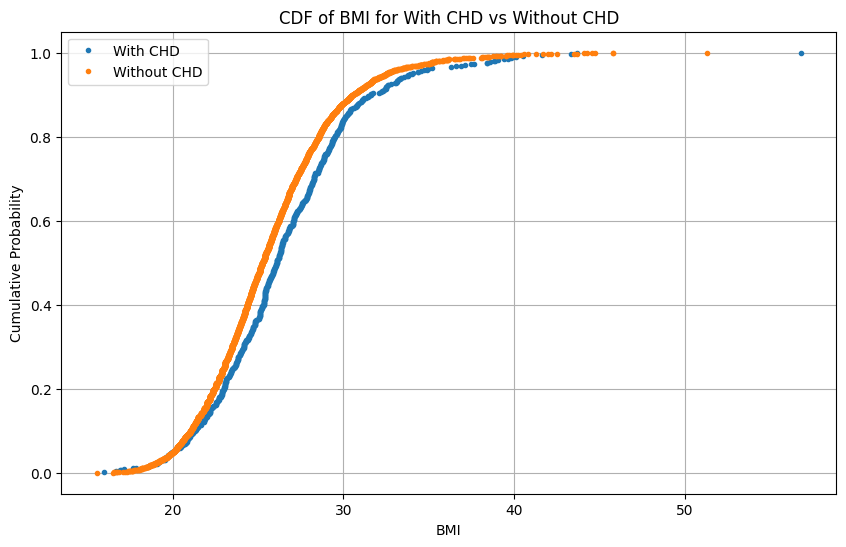

In [31]:
plot_cdf('BMI')

## Other CDFs

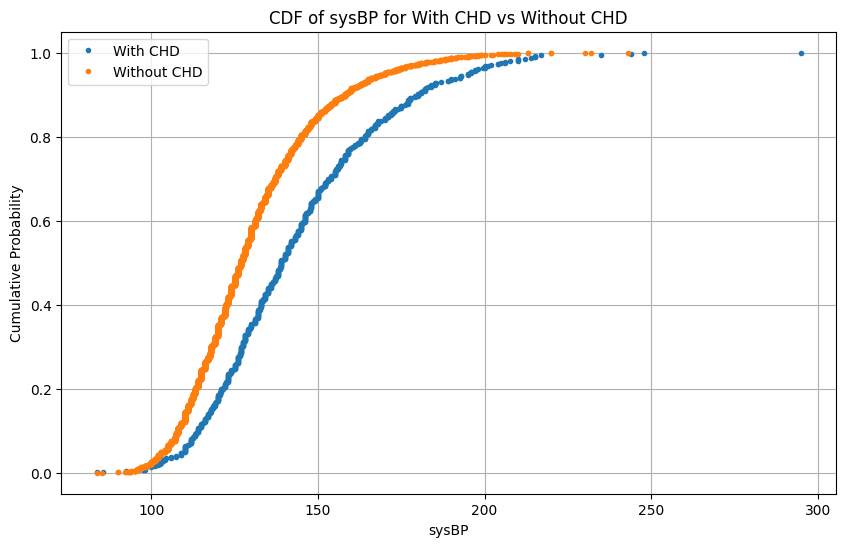

In [32]:
plot_cdf('sysBP')

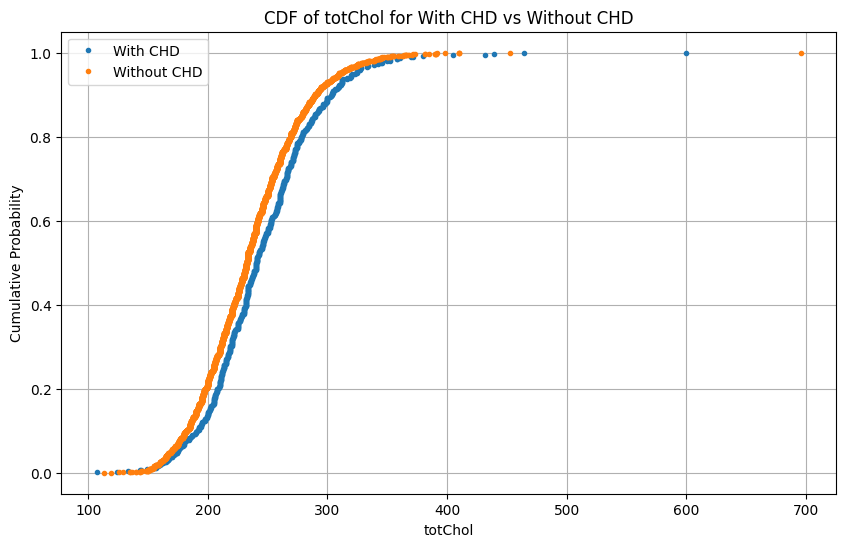

In [33]:
plot_cdf('totChol')

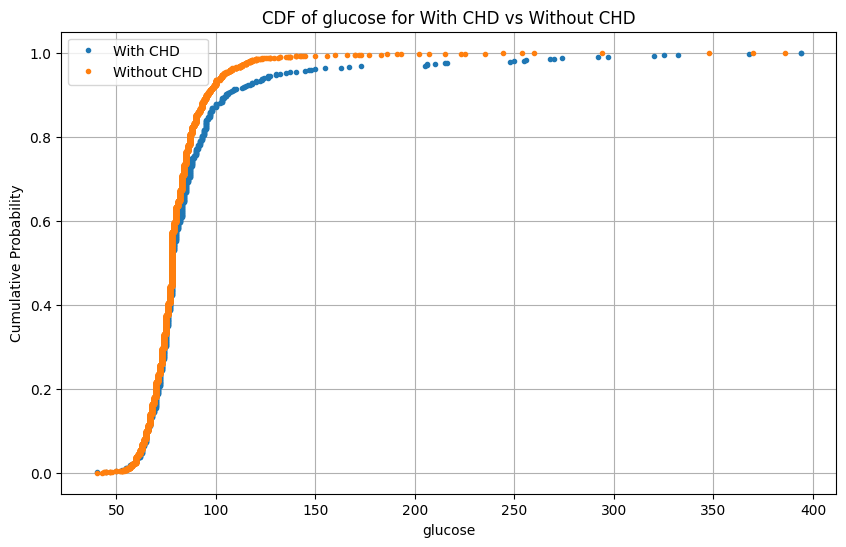

In [34]:
plot_cdf('glucose')

# Analytical Distributions
Here we compare a normalized distribution to the underlying data.

## Fit the normal distribution for BMI Data

In [35]:
# Fit a normal distribution to BMI data
mu, sigma = stats.norm.fit(df['BMI'])

## Normal Distribution Plot of BMI data compared to Probability Density Function (PDF)
This plot shows a comparison between the BMI Data distribution (blue bars) and a fitted normal distribution (black line).  By comparing these items, we can see that the normal distribution would predict more people with lower BMI than exist in the dataset.  This also shows that there are more people with higher BMI in the dataset than the normal distribution would expect.

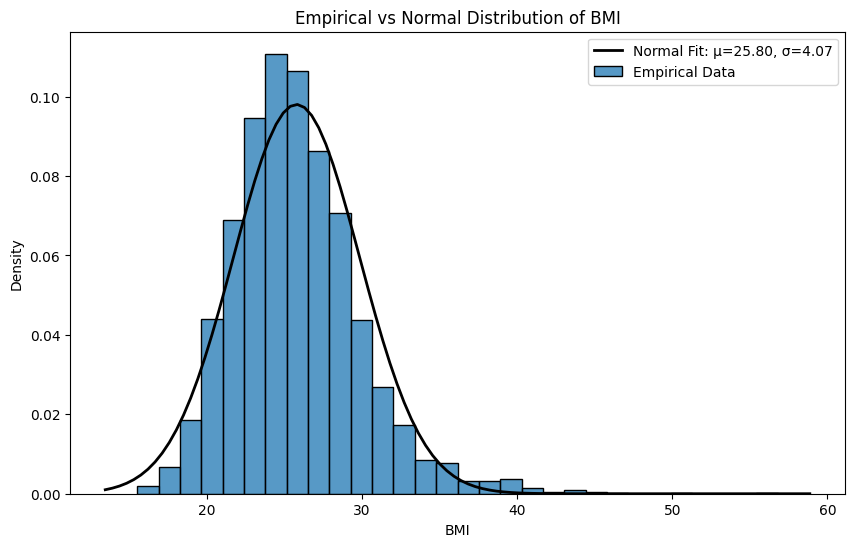

In [36]:
# Plot histogram of BMI
plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], kde=False, stat='density', bins=30, label='Empirical Data')

# Plot the PDF of the normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit: μ={mu:.2f}, σ={sigma:.2f}')

# Adding labels and title
plt.xlabel('BMI')
plt.ylabel('Density')
plt.title('Empirical vs Normal Distribution of BMI')
plt.legend()
plt.show()

### Q-Q Plot Confirmation
This QQ Plot confirms what we saw in the above plot.  We see noticably that the normal distribution predicts more instances of lower BMI than we see in the data set and fewer instances of high BMI than are present.

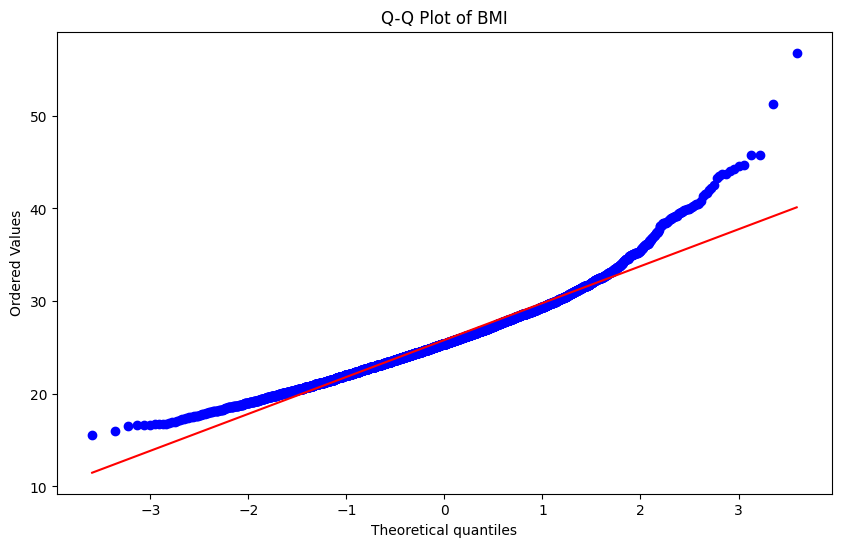

In [37]:
# Q-Q plot for BMI
plt.figure(figsize=(10, 6))
stats.probplot(df['BMI'], dist="norm", plot=plt)
plt.title('Q-Q Plot of BMI')
plt.show()

# Scatter Plot Analysis of Variables
Here we create scatter plots of continuous variables for analysis.

## Comparison of Systolic Blood Pressure (sysBP) and Total Cholesterol (totChol)
This graph shows the relationship between sysBP (primarily in the range 100 and 300 mg/dL) and totChol primarily in the range (100 and 200 mmHg). The color coding indicates whether the data is related to a person with CHD (1) and those without CHD (0).  Below the graph, we print the results of Pearson's R Correlation and Covariance analysis.  Pearson's Correlation Coefficient of 0.21 indicates a weak positive linear relationship between total cholesterol and systolic blood pressure.  The covariance metric of 202.52 indicates only that the two variables tend to increase together, it does not imply a strong relationship.

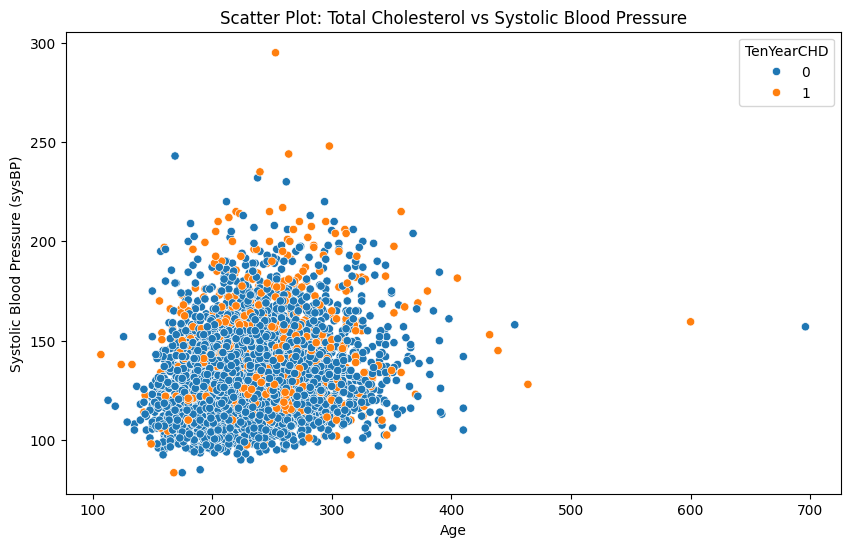

Pearson’s Correlation (totChol vs sysBP): 0.21
Covariance (totChol vs sysBP): 202.52


In [38]:
# Scatter plot and correlation analysis for Age vs Systolic Blood Pressure (sysBP)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='totChol', y='sysBP', hue='TenYearCHD', data=df)
plt.title('Scatter Plot: Total Cholesterol vs Systolic Blood Pressure')
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure (sysBP)')
plt.show()

# Calculate Pearson’s correlation and covariance for Age vs sysBP
corr_age_sysBP, _ = pearsonr(df['totChol'], df['sysBP'])
cov_age_sysBP = np.cov(df['totChol'], df['sysBP'])[0, 1]

print(f"Pearson’s Correlation (totChol vs sysBP): {corr_age_sysBP:.2f}")
print(f"Covariance (totChol vs sysBP): {cov_age_sysBP:.2f}")

## Comparison of Systolic Body Mass Index (BMI) and Glucose (glucose)
This plot shows the relationship between BMI and Glucose.  The color coding indicates whether the data is related to a person with CHD (1) and those without CHD (0). Below the graph, we print the results of Pearson's R Correlation and Covariance Analysis.  Pearson's Correlation Coefficient of 0.08 indicates there is almost no linear relationship between these two variables.  The Covariance value of 7.65 further suggests that there is little to no linear relationship.

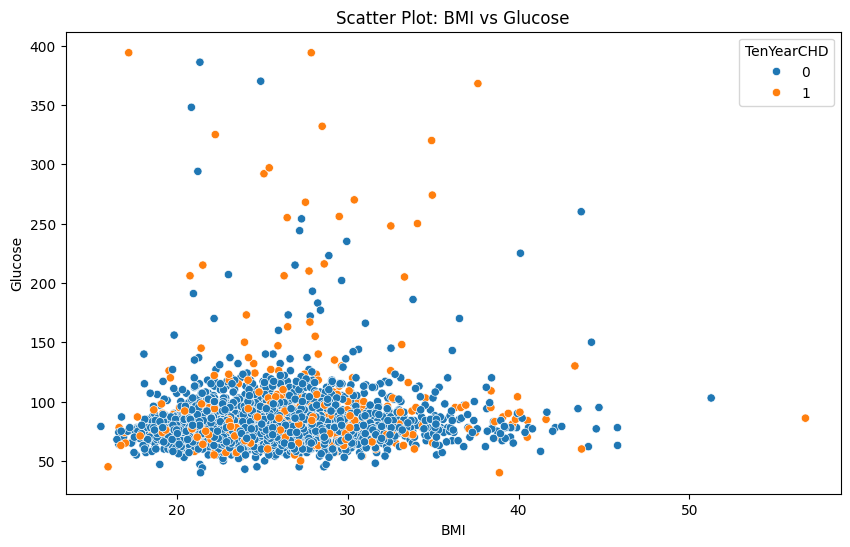

Pearson’s Correlation (BMI vs Glucose): 0.08
Covariance (BMI vs Glucose): 7.65


In [39]:
# Scatter plot and correlation analysis for BMI vs Glucose
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BMI', y='glucose', hue='TenYearCHD', data=df)
plt.title('Scatter Plot: BMI vs Glucose')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.show()

# Calculate Pearson’s correlation and covariance for BMI vs Glucose
corr_BMI_glucose, _ = pearsonr(df['BMI'], df['glucose'])
cov_BMI_glucose = np.cov(df['BMI'], df['glucose'])[0, 1]

print(f"Pearson’s Correlation (BMI vs Glucose): {corr_BMI_glucose:.2f}")
print(f"Covariance (BMI vs Glucose): {cov_BMI_glucose:.2f}")

# Hypothesis Testing
Here, we will explore methods of Hypothesis Testing.

## Mean Difference Test

### Establishing the Hypothesis
For this test, we will evaluate if the BMI mean is different between those with CHD and those without CHD.  

Null Hypothesis (H0): There is no difference between the means of the two groups.
Alternative Hypothesis (H1): There is a significant difference in the means of the two groups.

### Conduct the Test

#### Reusable Mean Permutation Test Code

In [40]:
def permutation_test(group1, group2, num_permutations=1000):
    combined = np.concatenate([group1, group2])
    diffs = []
    for _ in range(num_permutations):
        np.random.shuffle(combined)
        new_group1 = combined[:len(group1)]
        new_group2 = combined[len(group1):]
        diff_means = np.mean(new_group1) - np.mean(new_group2)
        diffs.append(diff_means)
    return np.array(diffs)

#### Establish the Groups

In [41]:
with_chd = df[df['TenYearCHD'] == 1]['BMI']  # With CHD
without_chd = df[df['TenYearCHD'] == 0]['BMI']  # Without CHD

#### Compute the observed test statistic (difference in means)

In [42]:
obs_diff_means = with_chd.mean() - without_chd.mean()

#### Simulate the sampling distribution and Calculate P-Value

In [43]:
# Simulate the sampling distribution
diff_means = permutation_test(with_chd, without_chd)

# Calculate the p-value
p_value = np.sum(np.abs(diff_means) >= np.abs(obs_diff_means)) / len(diff_means)

# Display results
print(f"Observed Difference in Means: {obs_diff_means:.2f}")
print(f"p-value: {p_value:.4f}")

Observed Difference in Means: 0.84
p-value: 0.0000


### Interpretation of Result
Since the p-value is less than 0.05, we will reject the null hypothesis. This indicates that there is a significant difference in the BMI means between those with CHD and those without CHD.

## Correlation Permutation Test

### Establishing the Hypothesis
For this test, we will evaluate if the BMI is significantly correlated with sysBP.  

Null Hypothesis (H0): There is not a significant correlation between BMI and sysBP.
Alternative Hypothesis (H1): There is a significant correlation between BMI and sysBP.

### Conduct the Test

#### Reusable Function for the test
This function can conduct either pearson or spearman's correlation test

In [44]:
# Function to calculate the permutation test for correlation
def correlation_permutation_test(x, y, num_permutations=1000, method='pearson'):
    # Calculate the observed correlation
    if method == 'pearson':
        observed_corr, _ = stats.pearsonr(x, y)
    elif method == 'spearman':
        observed_corr, _ = stats.spearmanr(x, y)
    else:
        raise ValueError("Method should be either 'pearson' or 'spearman'")
    
    permuted_corrs = []
    for _ in range(num_permutations):
        # Permute one of the variables
        y_permuted = np.random.permutation(y)
        # Calculate the correlation with the permuted data
        if method == 'pearson':
            permuted_corr, _ = stats.pearsonr(x, y_permuted)
        elif method == 'spearman':
            permuted_corr, _ = stats.spearmanr(x, y_permuted)
        permuted_corrs.append(permuted_corr)
    
    permuted_corrs = np.array(permuted_corrs)
    
    # Calculate the two-sided p-value
    p_value = np.sum(np.abs(permuted_corrs) >= np.abs(observed_corr)) / num_permutations
    
    return observed_corr, permuted_corrs, p_value

#### Set Up the Data

In [45]:
x = df['BMI']
y = df['sysBP']

#### Run the permutation using Pearson's correlation

In [46]:
observed_corr_pearson, permuted_corrs_pearson, p_value_pearson = correlation_permutation_test(x, y, method='pearson')
print(f'Pearson Observed Correlation: {observed_corr_pearson:.4f}')
print(f'Pearson Two-sided p-value: {p_value_pearson:.4f}')

Pearson Observed Correlation: 0.3251
Pearson Two-sided p-value: 0.0000


#### Plot Pearson's Correlation

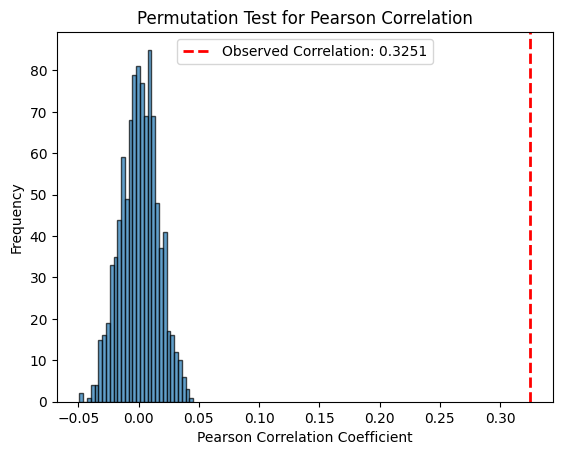

In [47]:
plt.hist(permuted_corrs_pearson, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(observed_corr_pearson, color='red', linestyle='--', linewidth=2, label=f'Observed Correlation: {observed_corr_pearson:.4f}')
plt.title('Permutation Test for Pearson Correlation')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### Run the permutation using Spearman's correlation.

In [48]:
observed_corr_spearman, permuted_corrs_spearman, p_value_spearman = correlation_permutation_test(x, y, method='spearman')
print(f'Spearman Observed Correlation: {observed_corr_spearman:.4f}')
print(f'Spearman Two-sided p-value: {p_value_spearman:.4f}')

Spearman Observed Correlation: 0.3230
Spearman Two-sided p-value: 0.0000


#### Plot the result of Spearman's Correlation

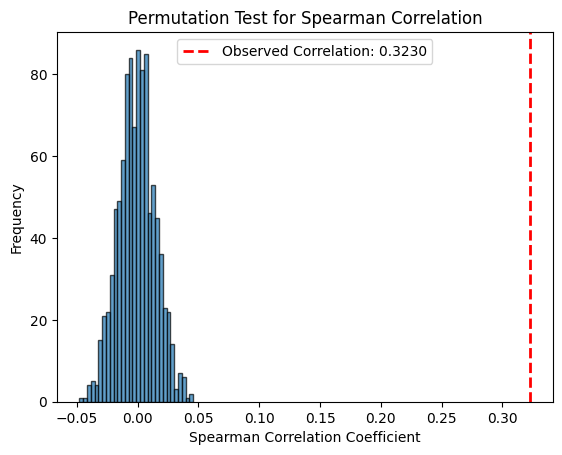

In [49]:
plt.hist(permuted_corrs_spearman, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(observed_corr_spearman, color='red', linestyle='--', linewidth=2, label=f'Observed Correlation: {observed_corr_spearman:.4f}')
plt.title('Permutation Test for Spearman Correlation')
plt.xlabel('Spearman Correlation Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Interpretation of Results
Both Pearson's and Spearman's correlations show that there is a correlation between the BMI and sysBP.  This means we can reject the null hypothesis that these variables are not correlated.  This confirms our observations for the mean difference test above.

# Regression

In this section, we will perform Simple and Multiple Linear Regression.  Since we will be performing linear regression here, we need to recall that linear regression assumes linearity and normality of the residuals.  Therefore, we will need to scale the data.

## Create data frame copy so we can restore after regression

In [50]:
og_data = df.copy()

## Scale the continuous variables

In [51]:
# Select continuous variables to normalize
continuous_vars = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'glucose']

# Initialize the scaler
scaler = StandardScaler()

# Apply normalization
df[continuous_vars] = scaler.fit_transform(df[continuous_vars])

## Simple Regression
In this regression, we are checking to see if BMI can predict sysBP.  From the results, BMI can predict only about 10.5% of variance in sysBP.  The high F-statistic and low p-value indicate that this model is statistically significant.  However, there are other factors which impact sysBP which are not in the model.  

In [52]:
# Define the dependent and explanatory variables
X = df['BMI']
y = df['sysBP']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the model using Ordinary Least Squares (OLS)
model = sm.OLS(y, X).fit()

# Display the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          6.13e-105
Time:                        19:09:35   Log-Likelihood:                -5779.5
No. Observations:                4240   AIC:                         1.156e+04
Df Residuals:                    4238   BIC:                         1.158e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.472e-17      0.015   -1.7e-15      1.0

## Multiple Linear Regression
In this regression, we are again looking to predict sysBP.  In addition to BMI which was in our previous model, we are bringing in other factors such as age, glucose, and totChol.  These additional variables have allowed the model to explain approximately 24% of the variance in Blood Pressure.  This indicates a moderate ability to predict blood pressure using these variables.  Our F-Statistic and p-value have moved in the right direction and the model remains statistically significant.  

In [53]:
# Define the dependent and explanatory variables
X = df[['age', 'glucose', 'BMI', 'totChol']]
y = df['sysBP']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the model using Ordinary Least Squares (OLS)
model = sm.OLS(y, X).fit()

# Display the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     339.4
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          9.51e-254
Time:                        19:09:35   Log-Likelihood:                -5426.8
No. Observations:                4240   AIC:                         1.086e+04
Df Residuals:                    4235   BIC:                         1.090e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.123e-17      0.013  -2.34e-15      1.0

## Summary of Regresion
As we evaluate the Regression results, it is important to understand that the intent of the regression is to evaluate the coefficient which indicates the expected change in the dependent variable based on a one-unit change in the predictor variable.  Based on the above model, for instance, we are evaluating the impact in sysBP based on a one unit change in age holding other variables constant.  We evaluate this impact for all other predictors as well (i.e., glucose, BMI, and totChol).  Our goal should be to identify variables that have strong, independent association with the dependent variable.

## Reset the Data Frame

In [54]:
df = og_data

# Summary

This analysis focused on analyzing the continuous variable relationships from the Framingham Heart Study (FHS).  In this analysis, we did not focus on attempting to predict the TenYearCHD because the intent was to demonstrate ability to apply Exploratory Data Analysis Techniques to better understand our Data.  The outcome of this effort would be to select features from the dataset which could be used to predict whether a patient has indicators of developing CHD within 10 years of an exam.  Assuming the data in this dataset could predict the risk of CHD, preventive action could be taken reduce the risk of serious health issues developing.

Through this EDA, we have evaluated several variables in the dataset.  We have seen that variable such as BMI can be good indicators of Systolic Blood Pressure. We have also seen that people with higher BMI are more likely to develop CHD within 10 years of an exam.  We have also seen that most of the data in this dataset is not normally distributed.  Additional analysis techniques could be used to determine the appropriate method for dealing with this data to reduce the impact of outliers, deal with multicollinearity that may exist, etc.  An example of how we could handle multicollinearity if we identified a need to do so would be to remove or cobine correlated variables or to apply regularization techniques such as Ridge or Lasso regression.

During this analysis, I have not evaluated how other non-continuous variables may impact the ability to predict CHD.  In addition, there were some data in this file that did not have appropriate definitions to use in the analysis (e.g., education level).  Along with these issues, I feel like there may be more value in obtaining access to more information from the FHS dataset.  For example, BMI is a calculation based on height and weight; it might actually be better to have these variables separately available.  Date of birth rather than age, date of examination, details about blood oxygen levels, resting vs active heart rate, distinct values for HDL and LDL Cholesterol levels (e.g., cholesterol ratio), and family history of CHD might also be good variables to include in this analysis.  It is likely that adding some of these additional variables could improve the predictability of CHD.  In addition, we might have been able to see additional linear relationships in those data that were not present in the current dataset.

I'm not sure that there were many assumptions that I made here.  I kind of let the data lead me.  In general though, I still feel challenged when interpreting the specific statistical outputs.  I spent a lot of time getting the code into a usable state to explore the data.  I intentionally avoided the use of the code from the textbook as I felt that it masked a lot of what was happening under the hood in the python libraries.  

I still lack confidence that I will be able to perform a rigorous analysis of a dataset without guidance.  I felt like this effort would have been better as a group assignment where team members could help each other and divide up the work.  There were so many data attributes that would have been interesting for analysis but due to time constraints, I do not feel like I did much justice to the complexity of this topic.  I felt like there were other analyses that I should have performed and that I should have spent more time trying to create predictive models for CHD.  

#  Scratch Pad
Everything After this point is additional analysis I performed on the dataset.  I am not confident that this is valuable information.  However, I am leaving it in in case there are any questions as to the level of time and effort spent exploring the data.

## Correlation Analysis
Here we will look at correlation amongst the variables.  We will look at correlation against the target variable to understand how each continuous variable correlates to the TenYearCHD.  We will also look to see if there is any multicollinearity amongst the variables.

### Target Variable Correlation
Here we will calculate the correlation amongst all fields in the dataset.  We will also caculate the p value of the correlation using Pearson's R.  Finally, we will identify all of the values in the correlation matrix that have a statistically significant relationship to other variables.

In [55]:
# Function to calculate correlation matrix with p-values
def corr_with_pvalues(df):
    df_corr = df.corr()
    pvals = pd.DataFrame(np.zeros_like(df_corr), columns=df_corr.columns, index=df_corr.index)
    
    for row in df_corr.columns:
        for col in df_corr.columns:
            if row != col:
                # Drop NaNs from both columns simultaneously to ensure matching lengths
                common_data = df[[row, col]].dropna()
                if len(common_data) > 1:  # Ensure there is data to calculate correlation
                    corr, pval = pearsonr(common_data[row], common_data[col])
                    pvals.at[row, col] = pval
                else:
                    pvals.at[row, col] = np.nan
    
    return df_corr, pvals

# Calculate correlations and p-values
corr_matrix, p_values = corr_with_pvalues(df)

# Define a significance level (commonly 0.05)
significance_level = 0.05

# Apply a mask to highlight significant correlations
significant_corr = corr_matrix[p_values < significance_level]

#### Initial Correlations

In [56]:
# Display correlations with significant values highlighted
print("Correlation Matrix:")
display(HTML(corr_matrix.to_html()))

Correlation Matrix:


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,age_binned,BMI_binned
male,1.000000,-0.029014,0.197026,0.314849,-0.051544,-0.004550,0.005853,0.015693,-0.069643,-0.035879,0.058199,0.081852,-0.116913,0.009970,0.088374,-0.028139,0.096827
age,-0.029014,1.000000,-0.213662,-0.192017,0.121011,0.057679,0.306799,0.101314,0.260527,0.394053,0.205586,0.135470,-0.012839,0.117878,0.225408,0.986634,0.129868
currentSmoker,0.197026,-0.213662,1.000000,0.760326,-0.048348,-0.032980,-0.103710,-0.044285,-0.046391,-0.130281,-0.107933,-0.167368,0.062678,-0.055082,0.019448,-0.209194,-0.156090
cigsPerDay,0.314849,-0.192017,0.760326,1.000000,-0.044697,-0.032248,-0.065541,-0.036173,-0.027134,-0.088393,-0.056768,-0.092647,0.074271,-0.056792,0.058729,-0.187310,-0.086543
BPMeds,-0.051544,0.121011,-0.048348,-0.044697,1.000000,0.114614,0.258580,0.051407,0.078642,0.251479,0.192254,0.099617,0.015136,0.049142,0.086448,0.120654,0.094741
prevalentStroke,-0.004550,0.057679,-0.032980,-0.032248,0.114614,1.000000,0.074791,0.006955,0.000160,0.057000,0.045153,0.024283,-0.017674,0.018730,0.061823,0.056895,0.007668
prevalentHyp,0.005853,0.306799,-0.103710,-0.065541,0.258580,0.074791,1.000000,0.077752,0.162696,0.696656,0.615840,0.300537,0.146777,0.083406,0.177458,0.304589,0.286267
diabetes,0.015693,0.101314,-0.044285,-0.036173,0.051407,0.006955,0.077752,1.000000,0.040186,0.111265,0.050260,0.086058,0.048986,0.606495,0.097344,0.099934,0.075436
totChol,-0.069643,0.260527,-0.046391,-0.027134,0.078642,0.000160,0.162696,0.040186,1.000000,0.207350,0.163408,0.115035,0.090534,0.045677,0.081749,0.258065,0.121777
sysBP,-0.035879,0.394053,-0.130281,-0.088393,0.251479,0.057000,0.696656,0.111265,0.207350,1.000000,0.783952,0.325087,0.182084,0.135091,0.216374,0.389102,0.296406


#### Heat Map of Correlation Matrix

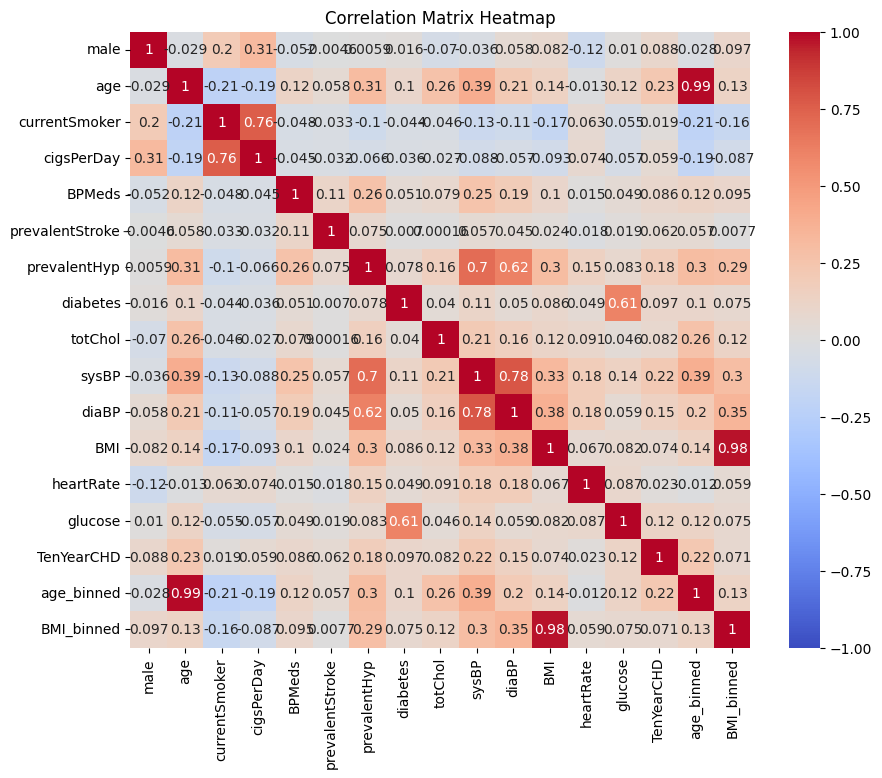

In [57]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

#### Correlation P-Values

In [58]:
print("\nP-Values Matrix:")
display(HTML(p_values.to_html()))


P-Values Matrix:


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,age_binned,BMI_binned
male,0.000000e+00,5.888269e-02,2.266686e-38,3.300834e-98,7.864453e-04,7.670661e-01,7.032033e-01,3.069605e-01,5.651808e-06,1.947370e-02,1.495784e-04,9.440754e-08,2.226931e-14,5.163084e-01,8.211735e-09,6.693610e-02,2.836961e-10
age,5.888269e-02,0.000000e+00,5.699049e-45,1.698440e-36,2.649395e-15,1.714273e-04,4.238820e-93,3.787300e-11,9.721707e-67,1.580371e-157,1.075413e-41,8.043438e-19,4.032654e-01,1.357732e-14,5.573313e-50,0.000000e+00,2.334517e-17
currentSmoker,2.266686e-38,5.699049e-45,0.000000e+00,0.000000e+00,1.637823e-03,3.175524e-02,1.293224e-11,3.923915e-03,2.515454e-03,1.635464e-17,1.833150e-12,5.181853e-28,4.424374e-05,3.328036e-04,2.054627e-01,3.845177e-43,1.850713e-24
cigsPerDay,3.300834e-98,1.698440e-36,0.000000e+00,0.000000e+00,3.602209e-03,3.574700e-02,1.945648e-05,1.849775e-02,7.729082e-02,8.151521e-09,2.170271e-04,1.503525e-09,1.288879e-06,2.156603e-04,1.300534e-04,8.816086e-35,1.751824e-08
BPMeds,7.864453e-04,2.649395e-15,1.637823e-03,3.602209e-03,0.000000e+00,7.122046e-14,9.730021e-66,8.121947e-04,2.940265e-07,3.672658e-62,1.389318e-36,7.986006e-11,3.244409e-01,1.369953e-03,1.720838e-08,3.198904e-15,6.788019e-10
prevalentStroke,7.670661e-01,1.714273e-04,3.175524e-02,3.574700e-02,7.122046e-14,0.000000e+00,1.085669e-06,6.507253e-01,9.916693e-01,2.044191e-04,3.273514e-03,1.138840e-01,2.499087e-01,2.227056e-01,5.619014e-05,2.100327e-04,6.182281e-01
prevalentHyp,7.032033e-01,4.238820e-93,1.293224e-11,1.945648e-05,9.730021e-66,1.085669e-06,0.000000e+00,3.998514e-07,1.533224e-26,0.000000e+00,0.000000e+00,3.103472e-89,7.493842e-22,5.361476e-08,2.452591e-31,1.004637e-91,1.607367e-80
diabetes,3.069605e-01,3.787300e-11,3.923915e-03,1.849775e-02,8.121947e-04,6.507253e-01,3.998514e-07,0.000000e+00,8.870213e-03,3.717865e-13,1.061031e-03,1.994857e-08,1.419258e-03,0.000000e+00,2.127852e-10,6.955188e-11,9.133614e-07
totChol,5.651808e-06,9.721707e-67,2.515454e-03,7.729082e-02,2.940265e-07,9.916693e-01,1.533224e-26,8.870213e-03,0.000000e+00,2.126126e-42,9.206399e-27,5.766749e-14,3.515352e-09,2.930353e-03,9.795875e-08,1.784192e-65,1.963219e-15
sysBP,1.947370e-02,1.580371e-157,1.635464e-17,8.151521e-09,3.672658e-62,2.044191e-04,0.000000e+00,3.717865e-13,2.126126e-42,0.000000e+00,0.000000e+00,6.132987e-105,6.263188e-33,1.005991e-18,4.217070e-46,2.625461e-153,1.859571e-86


#### Statistically Significant Correlations
Any records with NaN indicate the correlation is not significant.

In [59]:
print("\nSignificant Correlations:")
display(HTML(significant_corr.to_html()))


Significant Correlations:


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,age_binned,BMI_binned
male,1.000000,NaN,0.197026,0.314849,-0.051544,NaN,NaN,NaN,-0.069643,-0.035879,0.058199,0.081852,-0.116913,NaN,0.088374,NaN,0.096827
age,NaN,1.000000,-0.213662,-0.192017,0.121011,0.057679,0.306799,0.101314,0.260527,0.394053,0.205586,0.135470,NaN,0.117878,0.225408,0.986634,0.129868
currentSmoker,0.197026,-0.213662,1.000000,0.760326,-0.048348,-0.032980,-0.103710,-0.044285,-0.046391,-0.130281,-0.107933,-0.167368,0.062678,-0.055082,NaN,-0.209194,-0.156090
cigsPerDay,0.314849,-0.192017,0.760326,1.000000,-0.044697,-0.032248,-0.065541,-0.036173,NaN,-0.088393,-0.056768,-0.092647,0.074271,-0.056792,0.058729,-0.187310,-0.086543
BPMeds,-0.051544,0.121011,-0.048348,-0.044697,1.000000,0.114614,0.258580,0.051407,0.078642,0.251479,0.192254,0.099617,NaN,0.049142,0.086448,0.120654,0.094741
prevalentStroke,NaN,0.057679,-0.032980,-0.032248,0.114614,1.000000,0.074791,NaN,NaN,0.057000,0.045153,NaN,NaN,NaN,0.061823,0.056895,NaN
prevalentHyp,NaN,0.306799,-0.103710,-0.065541,0.258580,0.074791,1.000000,0.077752,0.162696,0.696656,0.615840,0.300537,0.146777,0.083406,0.177458,0.304589,0.286267
diabetes,NaN,0.101314,-0.044285,-0.036173,0.051407,NaN,0.077752,1.000000,0.040186,0.111265,0.050260,0.086058,0.048986,0.606495,0.097344,0.099934,0.075436
totChol,-0.069643,0.260527,-0.046391,NaN,0.078642,NaN,0.162696,0.040186,1.000000,0.207350,0.163408,0.115035,0.090534,0.045677,0.081749,0.258065,0.121777
sysBP,-0.035879,0.394053,-0.130281,-0.088393,0.251479,0.057000,0.696656,0.111265,0.207350,1.000000,0.783952,0.325087,0.182084,0.135091,0.216374,0.389102,0.296406


#### Filter Significant Predictors of TenYearCHD

In [60]:
# Extracting significant predictors excluding TenYearCHD
significant_predictors = significant_corr['TenYearCHD'].dropna().index.tolist()
if 'TenYearCHD' in significant_predictors:
    significant_predictors.remove('TenYearCHD')
if 'BMI_binned' in significant_predictors:
    significant_predictors.remove('BMI_binned')
if 'age_binned' in significant_predictors:
    significant_predictors.remove('age_binned')

print("Significant Predictors of TenYearCHD (excluding the target variable):")
print(significant_predictors)

Significant Predictors of TenYearCHD (excluding the target variable):
['male', 'age', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'glucose']


### Multicollinearity Analysis against TenYearCHD

#### Perform logistic regression to identify significane of predictors

In [61]:
# Select the significant predictors
X_significant = df[significant_predictors]
y = df['TenYearCHD']

# Add a constant to the model
X_significant = sm.add_constant(X_significant)

# Fit the logistic regression model
logit_model_significant = sm.Logit(y, X_significant).fit()

# Display the summary of the logistic regression model
print(logit_model_significant.summary())

Optimization terminated successfully.
         Current function value: 0.378461
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 4240
Model:                          Logit   Df Residuals:                     4227
Method:                           MLE   Df Model:                           12
Date:                Tue, 04 Nov 2025   Pseudo R-squ.:                  0.1115
Time:                        19:09:38   Log-Likelihood:                -1604.7
converged:                       True   LL-Null:                       -1806.1
Covariance Type:            nonrobust   LLR p-value:                 9.385e-79
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.2462      0.593    -13.904      0.000      -9.409      -7.084
male          

#### Assess Multicollinearity using Variance Inflation Factor (VIF)

In [62]:
# Calculate VIF for each significant predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X_significant.columns
vif_data["VIF"] = [variance_inflation_factor(X_significant.values, i) for i in range(X_significant.shape[1])]

print("VIF for Significant Predictors:")
print(vif_data)

VIF for Significant Predictors:
            feature         VIF
0             const  153.806267
1              male    1.160862
2               age    1.336706
3        cigsPerDay    1.173423
4            BPMeds    1.098358
5   prevalentStroke    1.017881
6      prevalentHyp    2.049726
7          diabetes    1.588915
8           totChol    1.101744
9             sysBP    3.710074
10            diaBP    2.941647
11              BMI    1.202630
12          glucose    1.602817


### Interpretation of VIF Results
From the VIF results, we can identify that there is not much multicollinearity among the variables in the model.  If we had values between 5 and 10 we would dig more into the variables to understand this multicollinearity.  However, since all VIF values are less than 5, we do not need to assess these relationships further.

In future models, we will look to reduce the number of variables by eliminating those that the current model indicates are non-significant in predicting TenYearCHD such as BPMeds and totChol.

## Continuous Variables Analysis

### Pair Plots

<Figure size 2000x1500 with 0 Axes>

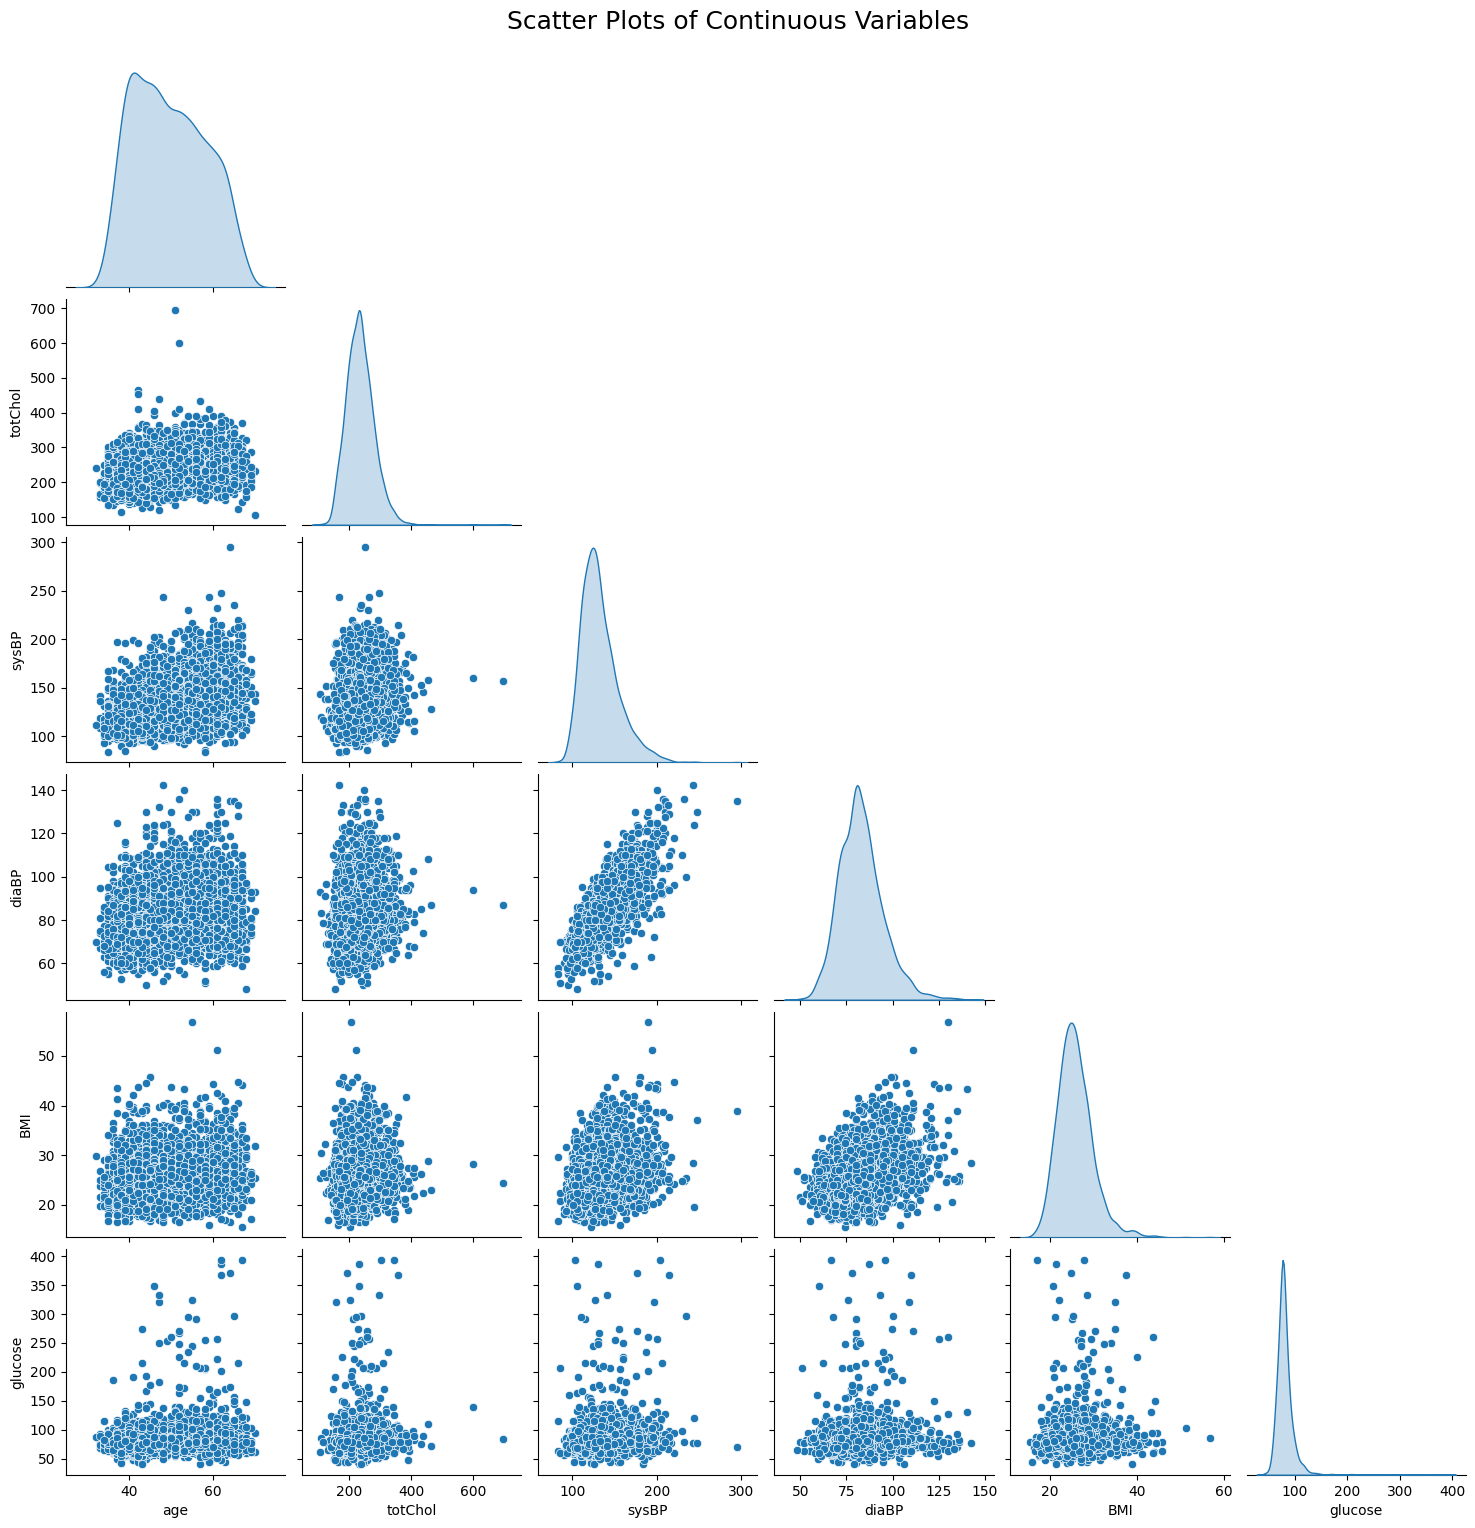

In [63]:
# Create scatter plots for each pair of variables
plt.figure(figsize=(20, 15))

# Using Seaborn's pairplot for automatic scatter plot generation
sns.pairplot(df[continuous_vars].dropna(), diag_kind='kde', corner=True)

plt.suptitle("Scatter Plots of Continuous Variables", y=1.02, fontsize=18)
plt.show()

### Boxplot for Outliers

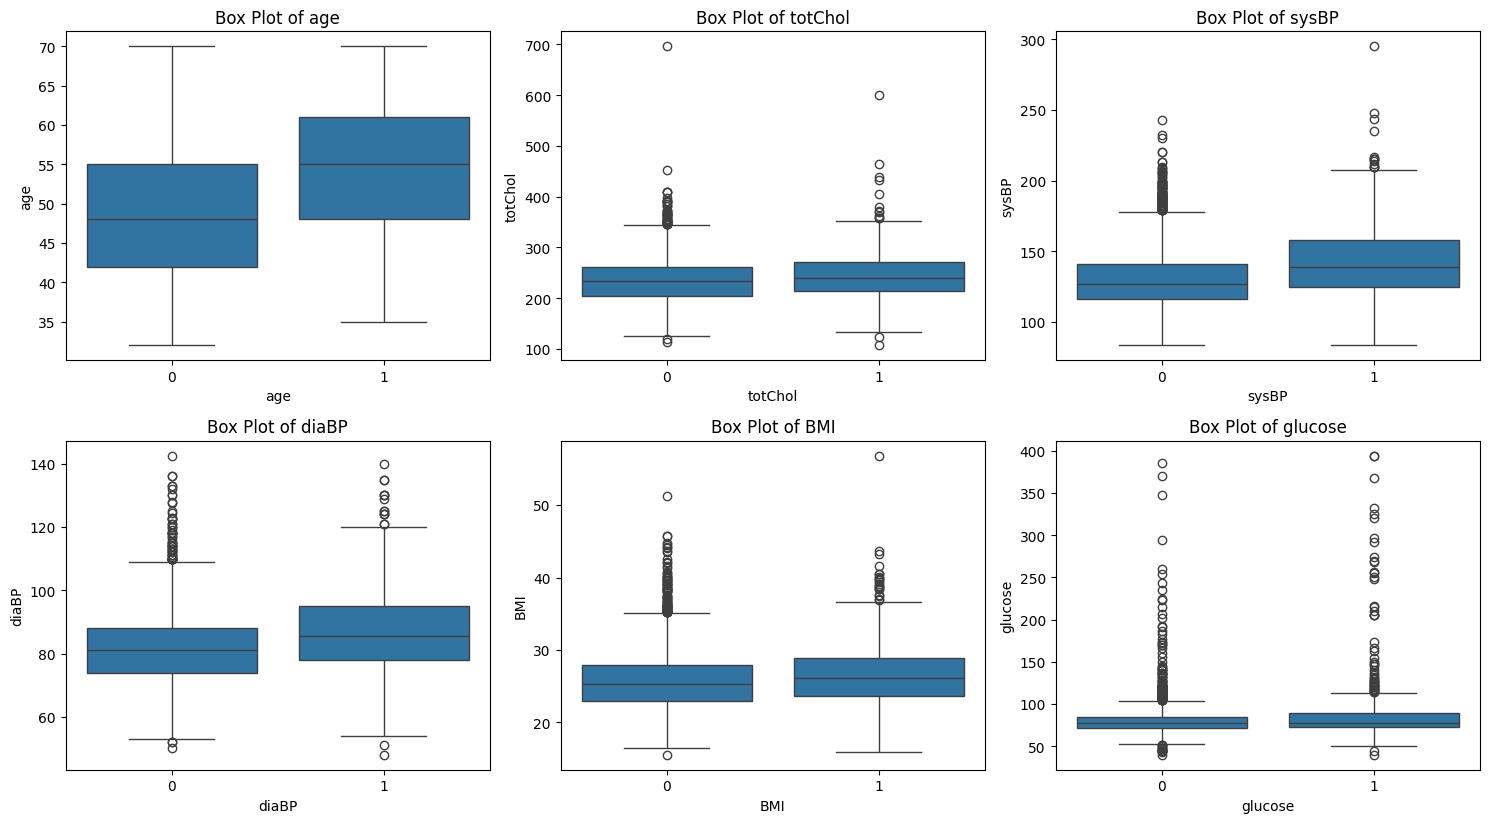

In [64]:
# Set up the plotting area
plt.figure(figsize=(15, 12))

# Loop through each variable and create a subplot for its box plot
for i, var in enumerate(continuous_vars):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, y=var, x=df['TenYearCHD'])
    plt.title(f'Box Plot of {var}')
    plt.xlabel(var)

plt.tight_layout()
plt.show()

## Explore significance of Outliers

### Calculate the correlation matrix with outliers included

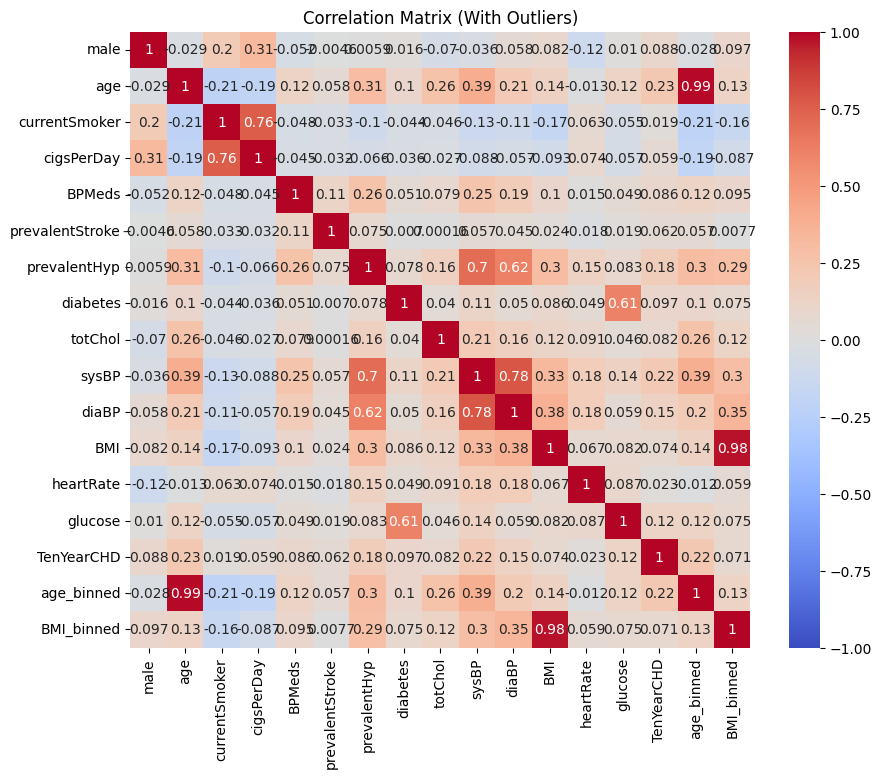

In [65]:
# Calculate the correlation matrix with outliers
correlation_matrix_with_outliers = df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_with_outliers, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (With Outliers)")
plt.show()

#### Remove outliers and recalculate correlations

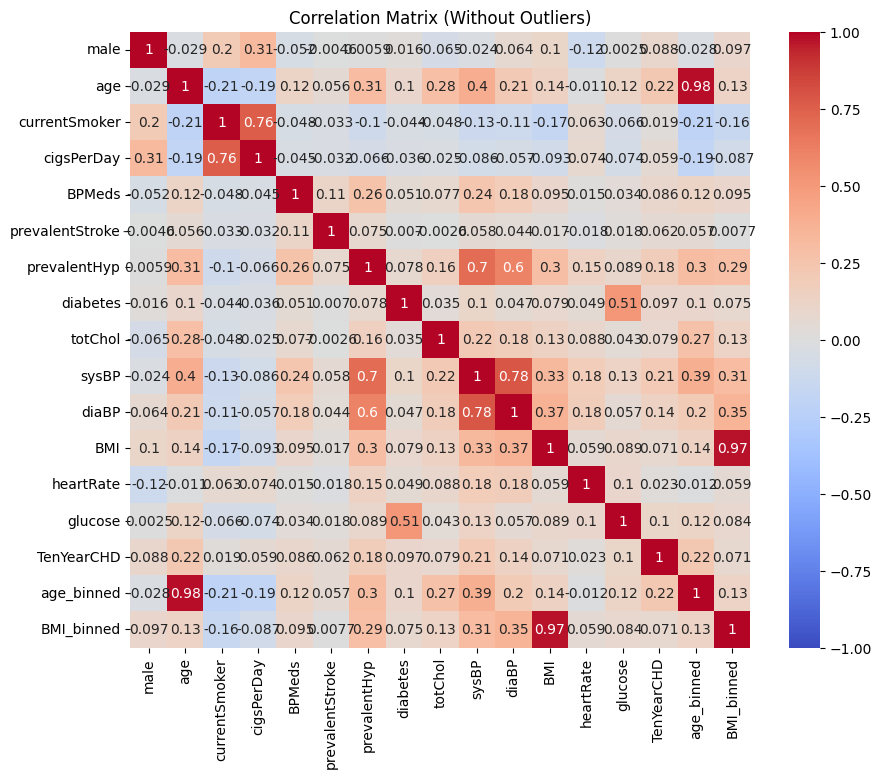

In [66]:
# Define a function to apply log transformation to specified columns
def log_transform_columns(df, columns):
    df_transformed = df.copy()
    for col in columns:
        # Apply log transformation, adding a small constant to avoid log(0)
        df_transformed[col] = np.log(df_transformed[col] + 1e-9)
    return df_transformed

# Define a function to remove outliers using the IQR method
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Remove outliers
# df_no_outliers = remove_outliers(df, continuous_vars)
df_no_outliers = log_transform_columns(df, continuous_vars)

# Calculate the correlation matrix without outliers
correlation_matrix_no_outliers = df_no_outliers.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_no_outliers, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Without Outliers)")
plt.show()

#### Compare the results

In [67]:
# Define the dependent and independent variables
X = df[continuous_vars]
y = df['TenYearCHD']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the model with outliers
model_with_outliers = sm.OLS(y, X).fit()
print("Regression Results with Outliers:")
print(model_with_outliers.summary())

# Fit the model without outliers
X_no_outliers = df_no_outliers[continuous_vars]
y_no_outliers = df_no_outliers['TenYearCHD']
X_no_outliers = sm.add_constant(X_no_outliers)

model_no_outliers = sm.OLS(y_no_outliers, X_no_outliers).fit()
print("\nRegression Results without Outliers:")
print(model_no_outliers.summary())

Regression Results with Outliers:
                            OLS Regression Results                            
Dep. Variable:             TenYearCHD   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     58.81
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.39e-70
Time:                        19:09:44   Log-Likelihood:                -1501.9
No. Observations:                4240   AIC:                             3018.
Df Residuals:                    4233   BIC:                             3062.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5

#### Interpretation of Results
This comparison indicates that the model without outliers is a better fit.  However, since this is medical data, these outliers could be significant for the prediction.  So, I'm going to perform a log transformation to handle specific outliers and see if that will improve the accuracy.

#### Apply Log Transformation

In [68]:
df_log_transformed = df.copy()

# Apply log transformation to each continuous variable
for var in continuous_vars:
    # Avoid log(0) by adding a small constant if necessary
    df_log_transformed[var] = np.log(df_log_transformed[var] + 1)

# Define the independent variables (log-transformed)
X_log = df_log_transformed[continuous_vars]
y_log = df['TenYearCHD']

# Add a constant to the model (intercept)
X_log = sm.add_constant(X_log)

# Fit the logistic regression model
logit_model_log = sm.Logit(y_log, X_log).fit()

# Display the summary of the regression model
print(logit_model_log.summary())

Optimization terminated successfully.
         Current function value: 0.390241
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 4240
Model:                          Logit   Df Residuals:                     4233
Method:                           MLE   Df Model:                            6
Date:                Tue, 04 Nov 2025   Pseudo R-squ.:                 0.08387
Time:                        19:09:44   Log-Likelihood:                -1654.6
converged:                       True   LL-Null:                       -1806.1
Covariance Type:            nonrobust   LLR p-value:                 1.891e-62
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -28.7647      2.164    -13.295      0.000     -33.005     -24.524
age            2.9572      0.

#### Logistic Regression Test

In [69]:
# Prepare the predictors (X) and target (y)
X = df_log_transformed[continuous_vars]
y = df['TenYearCHD']

# Initialize the logistic regression model
logreg = LogisticRegression(max_iter=1000)

# Perform 10-fold cross-validation
cv_scores = cross_val_score(logreg, X, y, cv=10, scoring='accuracy')

# Display the cross-validation scores
print("Cross-validation accuracy scores:", cv_scores)
print("Mean accuracy:", np.mean(cv_scores))
print("Standard deviation of accuracy:", np.std(cv_scores))

Cross-validation accuracy scores: [0.8490566  0.85141509 0.85141509 0.8490566  0.85141509 0.84669811
 0.85377358 0.84669811 0.8490566  0.84433962]
Mean accuracy: 0.8492924528301886
Standard deviation of accuracy: 0.002678730351792568


### Interpretation of Results
When using only the continuous variables for modeling, these variables are not a significant predictor alone.  From the above test, we can see that age, sysBP,  glucose, and cigsPerDay are more significant in this model.  Earlier, we saw when looking at all variables that the "significant_factors" regression also indicated that variables like totChol and diaBP were not significant so it makes sense they would not have much impact here.  

The logistic regression here run indicates that the model accuracy scores range from 0.8443 to 0.8561.  This indicates it will perform well across different subsets of the data.  The mean of 0.849 indicates that on average the model predicts the outcome for about 84.97% of cases.  The standard deviation of accuracy of 0.004 indicates stable model performance across different subsets of the data.

## Logistic Regression for TenYearCHD Prediction

In [70]:
# List of predictor variables
predictors = ['male', 'age', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'sysBP', 'glucose']

# Target variable
target = 'TenYearCHD'

# Check if we're on track
print("Ready for logistic regression with predictors:", predictors)

Ready for logistic regression with predictors: ['male', 'age', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'sysBP', 'glucose']


In [71]:
# Prepare the data for logistic regression
X = df[predictors]
y = df[target]

# Add a constant to the model
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X).fit()

# Display the summary of the logistic regression model
logit_summary = logit_model.summary()

logit_summary

Optimization terminated successfully.
         Current function value: 0.378859
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             TenYearCHD   No. Observations:                 4240
Model:                          Logit   Df Residuals:                     4230
Method:                           MLE   Df Model:                            9
Date:                Tue, 04 Nov 2025   Pseudo R-squ.:                  0.1106
Time:                        19:09:44   Log-Likelihood:                -1606.4
converged:                       True   LL-Null:                       -1806.1
Covariance Type:            nonrobust   LLR p-value:                 1.761e-80
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -7.9561      0.453    -17.549      0.000      -8.845      -7.068
male                0.4800      0.097      4.924      0.000       0.289       0.671
age                 0.0643      0.006     10.822      0.000       0.053       0.076
cigsPerDay          0.0218      0.004      5.675      0.000       0.014       0.029
BPMeds              0.2576      0.220      1.173      0.241      -0.173       0.688
prevalentStroke     0.9492      0.440      2.158      0.031       0.087       1.811
prevalentHyp        0.2251      0.126      1.781      0.075      -0.023       0.473
diabetes            0.2001      0.294      0.681      0.496      -0.376       0.776
sysBP               0.0133      0.003      4.962      0.000       0.008       0.019
glucose             0.0067      0.002      3.144      0.002       0.003       0.011
===================================================================================
"""

### Calculate and visualize residuals

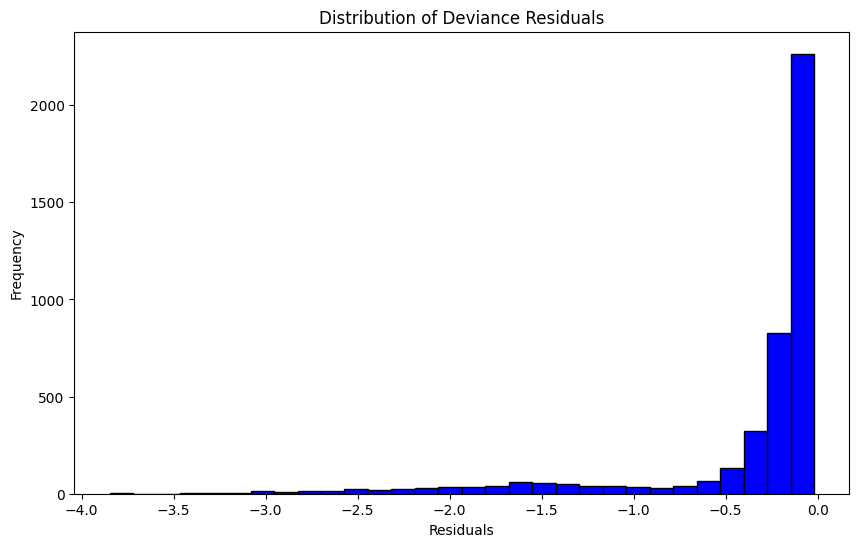

In [72]:
# Calculate predicted probabilities
predicted_probs = logit_model.predict(X)

# Calculate residuals (deviance residuals)
residuals = y * np.log(predicted_probs) + (1 - y) * np.log(1 - predicted_probs)

# Plot residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Deviance Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

### Calculate ROC Curve

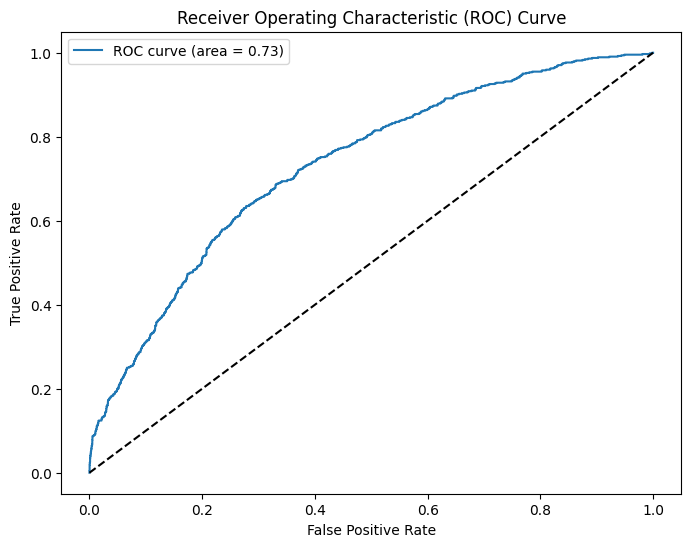

AUC Score: 0.73


In [73]:
fpr, tpr, thresholds = roc_curve(y, predicted_probs)

# Calculate AUC
auc_score = roc_auc_score(y, predicted_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='best')
plt.show()

print(f"AUC Score: {auc_score:.2f}")

### Calculate VIF for Predictors

In [74]:
# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data

,feature,VIF
0,const,95.829324
1,male,1.117737
2,age,1.231634
3,cigsPerDay,1.155538
4,BPMeds,1.097371
5,prevalentStroke,1.017378
6,prevalentHyp,1.984273
7,diabetes,1.586230
8,sysBP,2.127315
9,glucose,1.599118
